# Motorforsikring: innlasting, datarensing og kvalitetskontroll

Notebooken viser resultatene fra datakvalitetsmodulen. Variabelordbok,
rensing og integritetsdiagnostikk ligger i `src/data_quality.py`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupKFold

from src.coverage_visuals import (
    plot_coverage_by_policy_type_heatmap,
    plot_response_volume,
)
from src.data_quality import (
    build_integrity_diagnostics,
    build_variable_dictionary,
    clean_motor_data,
    find_variables,
    run_integrity_checks,
)
from src.own_damage_descriptives import (
    CATEGORICAL_VARS,
    NUMERIC_VARS,
    build_age_diagnostics,
    build_brand_distribution,
    build_brand_one_way,
    build_categorical_association,
    build_categorical_one_way,
    build_claim_count_distribution,
    build_missingness_outcome_comparison,
    build_numeric_correlation,
    build_numeric_one_way,
    build_overdispersion_summary,
    build_pure_premium_distribution_fit,
    build_pure_premium_summary,
    build_severity_distribution_fit,
    build_severity_summary,
    build_year_trend_summary,
    plot_age_diagnostics,
    plot_brand_distribution,
    plot_brand_one_way,
    plot_categorical_association_heatmap,
    plot_categorical_predictor_bars,
    plot_claim_count_distribution,
    plot_missingness_summary,
    plot_numeric_by_category_boxplot,
    plot_numeric_correlation_heatmap,
    plot_numeric_predictor_histograms,
    plot_one_way,
    plot_one_way_grid,
    plot_pure_premium_distribution,
    plot_severity_distribution,
    plot_year_trend,
)
from src.model_data import (
    BRAND_MIN_EXPOSURE,
    TEST_YEAR,
    TRAIN_YEARS,
    add_transparent_predictors,
    learn_retained_brands,
    select_own_damage_scope,
    split_by_year,
)
from src.portfolio_visuals import (
    plot_exposure_structure,
    plot_policy_type_composition,
)
from src.pre_split_diagnostics import (
    build_own_damage_scope_validation,
    build_pre_split_diagnostics,
)
from src.train_test_split import build_split_summary

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
DATA_PATH = Path("data/Dataset of motor insurance portfolio.csv")
DESCRIPTION_PATH = Path("data/Descriptive of variables.xlsx")
if not DATA_PATH.exists() or not DESCRIPTION_PATH.exists():
    raise FileNotFoundError(
        "Kjør notebooken fra prosjektroten slik at begge filene i data/ er tilgjengelige."
    )

seed = 100

# Arbeidsantakelser og sentrale begrensninger

Før den videre analysen gjør vi følgende eksplisitte antakelser:

- **Skadebeløpene brukes som levert i datasettet.** Artikkelen dokumenterer ikke om `property_incurred` er inflasjonsjustert eller indeksert, hvilket basisår som eventuelt er brukt, eller hvilken
verdsettelsesdato beløpene gjelder. Vi foretar derfor ingen egen inflasjonsjustering og antar ikke at beløpene er indeksregulert.

- **`property_incurred` behandles som beste tilgjengelige kostnadsmål, men ikke nødvendigvis som ultimate skadebeløp.** Artikkelen beskriver `incurred` som betalte beløp pluss utestående reserver, men gir ingen
full dokumentasjon av skadeutvikling eller IBNR. Se [artikkelen](https://pmc.ncbi.nlm.nih.gov/articles/PMC13234478/).

- **IBNR antas å være mindre problematisk for egen-skade enn for ansvarsskade**, fordi egen-skader normalt har kortere rapporterings- og oppgjørstid. Dette er likevel en praktisk arbeidsantakelse, ikke noe som
kan verifiseres direkte fra datasettet.

- **2024 behandles som et out-of-time-testsett for registrerte incurred-skader.** Publisering av datasettet i 2026 gjør det mulig at 2024-skadene er mer utviklet enn ved utgangen av 2024, men artikkelen oppgir
ikke datauttrekksdato eller at skadebeløpene er ferdig utviklet. Testresultatene må derfor tolkes som ytelse mot registrerte/påløpte skadebeløp i uttrekket, ikke nødvendigvis mot ultimate kostnader.

- **Modellvalg og variabelseleksjon baseres på 2022–2023.** 2024 holdes av til endelig evaluering og brukes ikke til å velge modell eller variabler. Vi må samtidig erkjenne at aggregerte testutfall allerede er
synlige i den deskriptive analysen, slik at testsettet ikke lenger er fullstendig blindt.

Disse antakelsene er en nødvendig forenkling for prosjektet. De innebærer at vi ikke tolker årseffekter som ren skadeinflasjon, og at vi omtaler resultatene som betinget på skadeutviklingen som foreligger i
datasettet.


## 1. Uendret innlasting og første inspeksjon

CSV-en leses før rensing. Excel-filen brukes som kildekontroll, mens den
forbedrede variabelordboken bygges i scriptet.

In [2]:
raw_data = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8", low_memory=False)
source_dictionary_raw = pd.read_excel(
    DESCRIPTION_PATH,
    sheet_name="Cartera",
    usecols=["Variables", "Description", "Group"],
)
source_variables = source_dictionary_raw["Variables"].dropna().astype(str).tolist()
variable_dictionary = build_variable_dictionary()
raw_overview = pd.Series(
    {
        "Antall rader": len(raw_data),
        "Antall kolonner": raw_data.shape[1],
        "Unike insured_id": raw_data["insured_id"].nunique(),
        "Duplikate hele rader": int(raw_data.duplicated().sum()),
        "Duplikate (insured_id, year)": int(
            raw_data.duplicated(["insured_id", "year"]).sum()
        ),
        "Minste år": int(raw_data["year"].min()),
        "Største år": int(raw_data["year"].max()),
        "Variabler dokumentert i Excel": len(source_variables),
        "Excel- og CSV-variabler er identiske": source_variables
        == raw_data.columns.tolist(),
        "Minnestørrelse (MiB)": round(
            raw_data.memory_usage(deep=True).sum() / 1024**2, 1
        ),
    },
    name="Verdi",
).to_frame()
display(raw_overview)
display(raw_data.head())

,Verdi
Antall rader,354140
Antall kolonner,47
Unike insured_id,185678
Duplikate hele rader,0
"Duplikate (insured_id, year)",0
Minste år,2022
Største år,2024
Variabler dokumentert i Excel,47
Excel- og CSV-variabler er identiske,True
Minnestørrelse (MiB),257.4


,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure
0,1,2022,COMP_E,C,NB,A,G,48,22.0,26.0,G,149511.4425,4,3.92,PORSCHE,I,U,279.557558,30.602324,121.912690,112.361489,3.832441,8.305788,2.043622,0.499205,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.09863,0.09863
1,2,2022,COMP_E,A,P,A,G,43,24.0,19.0,D,65065.1232,8,10.15,MERCEDES,I,U,546.623415,114.333356,303.105967,80.784824,7.826861,30.091751,7.812747,2.667908,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
2,2,2023,COMP_E,A,P,A,G,44,25.0,19.0,D,65065.1232,8,10.15,MERCEDES,I,U,548.752558,110.666891,304.955990,83.521384,6.151465,32.861626,7.655637,2.939566,1,1,1,0,0,0,0,0,0,0,233.0130,233.013,233.013,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
3,2,2024,COMP_E,A,P,A,G,45,26.0,18.0,D,65065.1232,8,10.15,MERCEDES,I,U,584.632430,122.092532,305.225093,107.886872,5.842892,31.101584,10.084173,2.399283,2,1,1,0,1,0,0,0,0,0,2586.3615,1035.000,1035.000,0.0,1551.3615,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
4,3,2022,COMP_E,A,NB,S,G,45,26.0,19.0,D,51626.6625,7,9.19,KIA,I,R,687.490508,214.583989,354.874140,53.077620,7.715765,48.574298,6.700701,1.963995,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000


In [3]:
raw_schema = pd.DataFrame(
    {
        "raw_dtype": raw_data.dtypes.astype(str),
        "missing_count": raw_data.isna().sum(),
        "missing_percent": raw_data.isna().mean().mul(100).round(4),
        "unique_count": raw_data.nunique(dropna=False),
        "example": [
            raw_data[column].dropna().iloc[0]
            if raw_data[column].notna().any()
            else pd.NA
            for column in raw_data.columns
        ],
    }
)
display(raw_schema)
display(
    raw_data.isna()
    .groupby(raw_data["year"])
    .sum()
    .loc[:, lambda frame: frame.sum().gt(0)]
    .T
)

,raw_dtype,missing_count,missing_percent,unique_count,example
insured_id,int64,0,0.0000,185678,1
year,int64,0,0.0000,3,2022
policy_type,str,0,0.0000,5,COMP_E
policy_status,str,0,0.0000,2,C
business_type,str,0,0.0000,2,NB
payment_frequency,str,0,0.0000,3,A
bonus_score,str,0,0.0000,3,G
driver_age,int64,0,0.0000,73,48
vehicle_age,float64,2,0.0006,69,22.0
age_driving_licence,float64,2,0.0006,72,26.0


year,2022,2023,2024
vehicle_age,0,1,1
age_driving_licence,0,1,1
fuel_type,171,397,719
vehicle_value,111,173,229


## 2. Variabelordbok

`variable_dictionary` er en dataframe bygget i scriptet og kan filtreres
senere med `find_variables(variable_dictionary, ...)`.

In [4]:
display(find_variables(variable_dictionary, search="policy_type"))

,variable,group,description,unit_or_codes,analysis_role,clean_dtype,missing_allowed
0,policy_type,Polise og kontrakt,Overordnet produkt-/dekningsstruktur for polisen.,TP=ansvar; TPG=ansvar+glass; CC=ansvar+minst to tilleggsdekninger; COMP_E=kasko med egenandel; COMP_N=kasko uten ege...,Kategorisk risikofaktor,category,Nei


In [5]:
raw_data[raw_data["power_to_weight_ratio"] <= 0].head()

,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure
350755,182681,2023,TPG,A,NB,A,G,39,16.0,23.0,D,27469.163925,3,0.0,IVECO,I,R,112.830837,90.701099,0.000000,0.000000,0.000000,19.966862,1.743789,0.419087,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394521,0.394521
350756,182681,2024,TPG,A,P,A,G,40,16.0,23.0,D,27469.163925,3,0.0,IVECO,I,R,291.139488,231.140084,0.000000,0.000000,0.000000,54.117296,4.718680,1.163429,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
353855,185394,2024,COMP_E,A,NB,A,G,51,33.0,18.0,D,26273.751000,3,0.0,IVECO,C,U,75.060590,25.086733,39.690763,3.599475,0.271363,5.209388,0.926287,0.276582,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106849,0.106849


## 3. Beslutninger etter datakontroll

Følgende beslutninger gjelder dette datasettet:

- `power_to_weight_ratio <= 0` settes til manglende. Tre rader omfattes.
- Kildedokumentasjonen for `age_driving_licence` og `vehicle_age` er
  selvmotsigende. Arbeidshypotesen, som testes eksplisitt i seksjon 17, er at
  `age_driving_licence` er alder ved førerkorterverv og at `vehicle_age` i
  praksis er førerkortansiennitet. Dette er ikke endelig bevist siden
  transformasjonskoden ikke er publisert. Reell kjøretøyalder behandles derfor
  som utilgjengelig og `vehicle_age` brukes ikke som modellprediktor.
- En kansellert polise med full eksponering beholdes uendret.
- Skader med null `incurred` beholdes som nullskader.
- Polise `(insured_id=23744, year=2022)` har en ansvarsskade, men null
  eksponering. Både `total_exposure` og `liability_exposure` settes til 1, slik
  at de fortsatt er konsistente.
- Positiv ansvarseksponering med null ansvarspremie beholdes. Kontrollen fant 23
  slike rader for 17 poliser; én av polisene har positiv ansvarspremie i senere
  år. Nullpremien behandles derfor som et premieavvik, ikke som null risiko.
  Radene skal flagges ved senere premieanalyse, men eksponeringen brukes i
  skademodeller.

## 4. Rensing

Rensingen låser skjema og datatyper, standardiserer kategorier og utfører de
dokumenterte korreksjonene over. Ingen rader slettes eller imputeres.

In [6]:
data, cleaning_log = clean_motor_data(raw_data, variable_dictionary)
display(cleaning_log)
display(
    pd.DataFrame(
        {
            "raw_dtype": raw_data.dtypes.astype(str),
            "clean_dtype": data.dtypes.astype(str),
            "missing_after_cleaning": data.isna().sum(),
        }
    )
    .sort_values("missing_after_cleaning", ascending=False)
    .head(6)
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poliseår-nøkkel",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til manglende,3,Standardisert
3,Manglende total- og ansvarseksponering satt til 1 for ansvarsskade,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,raw_dtype,clean_dtype,missing_after_cleaning
fuel_type,str,category,1287
vehicle_value,float64,float64,513
power_to_weight_ratio,float64,float64,3
vehicle_age,float64,Int16,2
age_driving_licence,float64,Int16,2
year,int64,Int16,0


In [7]:
display(
    data.loc[
        data["power_to_weight_ratio"].isna(),
        ["insured_id", "year", "power_to_weight_ratio"],
    ]
)

,insured_id,year,power_to_weight_ratio
350755,182681,2023,NaN
350756,182681,2024,NaN
353855,185394,2024,NaN


## 5. Integritetsdiagnostikk

Alle kontroller kjøres i scriptet. Notebooken presenterer oppsummeringene og
beholder dem som dataframes/datastrukturer for senere oppslag.

In [8]:
integrity_checks = run_integrity_checks(data, variable_dictionary)
diagnostics = build_integrity_diagnostics(data, integrity_checks)
critical_failures = diagnostics["critical_failures"]
warning_examples = diagnostics["warning_examples"]
coverage_diagnostics = diagnostics["coverage_diagnostics"]
temporal_diagnostics = diagnostics["temporal_diagnostics"]
display(integrity_checks)
display(warning_examples)
display(coverage_diagnostics)
display(temporal_diagnostics)
if not critical_failures.empty:
    raise AssertionError(
        "Minst én kritisk integritetskontroll feilet. Se critical_failures."
    )

,check,severity,expectation,violating_rows,status
0,"Unik (insured_id, year)",Kritisk,Ingen duplikate poliseår,0,Bestått
1,Manglende i obligatoriske felt,Kritisk,Ingen manglende verdier,0,Bestått
2,Endelige numeriske verdier,Kritisk,Ingen +inf eller -inf,0,Bestått
3,Ikke-negative premier,Kritisk,Alle premier >= 0,0,Bestått
4,Ikke-negative skadeantall,Kritisk,Alle skadeantall >= 0,0,Bestått
5,Ikke-negative incurred-beløp,Kritisk,Alle incurred-beløp >= 0,0,Bestått
6,Eksponering innenfor gyldig område,Kritisk,"Begge eksponeringer i [0, 1]",0,Bestått
7,Totalpremie summerer,Kritisk,total_premium = sum dekningspremier,0,Bestått
8,Totalt skadeantall summerer,Kritisk,total_claims = sum skadeantall per dekning,0,Bestått
9,Ansvarsskadeantall summerer,Kritisk,liability_claims = property + injury under ansvar,0,Bestått


,check,insured_id,year,policy_type,policy_status,business_type,age_driving_licence,liability_premium,total_premium,total_claims,total_incurred,total_exposure
0,Positiv ansvarseksponering med null ansvarspremie,50075,2022,CC,A,NB,20,0.0,44.522410,0,0.0,0.539726
1,Positiv ansvarseksponering med null ansvarspremie,73579,2023,COMP_E,A,NB,20,0.0,107.349196,0,0.0,0.369863
2,Positiv ansvarseksponering med null ansvarspremie,73579,2024,COMP_E,A,NB,19,0.0,294.780318,0,0.0,1.000000
3,Positiv ansvarseksponering med null ansvarspremie,78590,2023,COMP_E,A,NB,19,0.0,269.079700,0,0.0,0.813699
4,Positiv ansvarseksponering med null ansvarspremie,78590,2024,COMP_E,A,NB,19,0.0,326.888858,0,0.0,1.000000


,coverage,zero_premium_rows,claim_with_zero_premium,incurred_with_zero_premium
0,Ansvar,72,1,1
1,Egen skade,244802,2,2
2,Tyveri,42180,0,0
3,Brann,42183,0,0
4,Glass,5839,0,0
5,Rettshjelp,67,0,0
6,Passasjer,69,0,0


,variable,comparable_transitions,unchanged,decrease,increase_larger_than_year_gap
0,driver_age,168462,54527,42,14
1,vehicle_age,168461,54494,113,77
2,age_driving_licence,168461,147969,19571,57


## 6. Renseutfall og avgrensning for neste fase

Det rensede analysegrunnlaget ligger i `data`. Ingen rader er slettet og ingen
verdier er imputert. Diagnosene er funn som må vurderes før modellering.

# Deskriptiv analyse

Før train/test-splitt gjør vi bare strukturell porteføljediagnostikk. Tabellene
under brukes til å definere risikopopulasjoner og vurdere tidsstrukturen, ikke
til å velge prediktorer eller transformasjoner fra skadeutfall.

## 7. Porteføljestørrelse, eksponering og panelstruktur

Eksponeringsstatus per år (null / delår / full år) viser porteføljens vekst
og at andelen fullårseksponerte poliser øker mot 2024. Panelstrukturen —
hvor lenge poliser observeres — begrunner en tidsbasert train/test-splitt
fremfor en tilfeldig radsplitt: samme polise opptrer typisk i flere år.

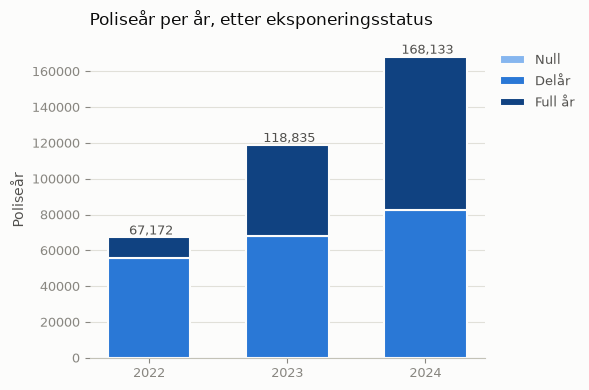

In [9]:
pre_split = build_pre_split_diagnostics(data)
display(plot_exposure_structure(data))

In [10]:
display(pre_split["panel_duration"])

,observerte_år,antall_poliser
0,1,67743
1,2,67408
2,3,50527


48 poliser har null eksponering og null premie i 2024 (aktive i 2022/2023,
men ikke fornyet). De beholdes i datasettet for sporbarhet, men utelates fra
skadeanalysen og train/test-splitten siden de ikke representerer risiko i
noen periode med positiv eksponering.

In [11]:
assert pre_split["exposure_checks"]["antall_poliseår"].eq(0).all(), (
    "Uventet avvik i eksponeringskontrollen — se build_exposure_summary."
)

## 8. Porteføljesammensetning: policy_type

`policy_type` er den sentrale klassifiseringsvariabelen for dekning (se
dekningsmatrisen under) og er stabil over tid. Øvrige
sammensetningsvariabler er ikke kritiske for avgrensningsbeslutningen;
`vehicle_brand` har særlig mange nivåer og egner seg bedre som prediktor
senere i analysen enn som deskriptiv oversikt her.

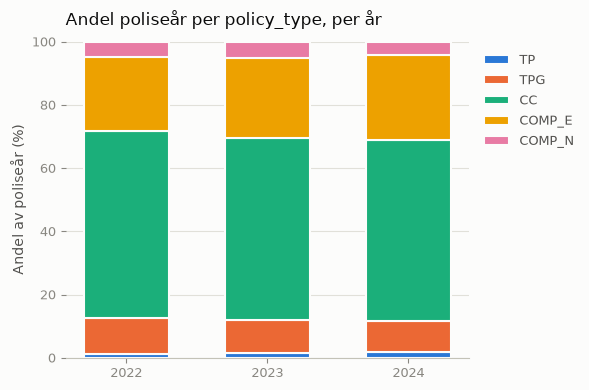

In [12]:
display(plot_policy_type_composition(data))

## 9. Dekningsmatrise

Ansvar anses aktivt når `liability_exposure > 0`. For andre dekninger brukes
positiv totaleksponering og positiv dekningspremie som en praktisk proxy for
at dekningen er aktiv (ingen per-dekning eksponeringsvariabel finnes).
Matrisen viser at egen skade (kasko) kun er aktiv for `policy_type` CC,
COMP_E og COMP_N — konsistent med at TP/TPG er rene ansvarsprodukter.

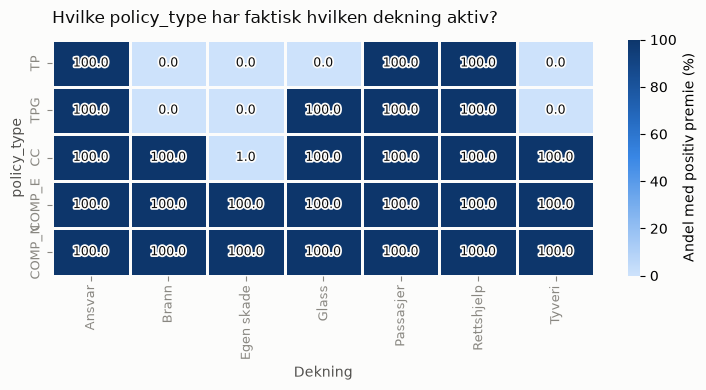

In [13]:
display(plot_coverage_by_policy_type_heatmap(pre_split["coverage_by_policy_type"]))

In [14]:
display(pre_split["coverage_summary"])

,dekning,regel_for_aktiv_dekning,poliseår_i_risiko,samlet_eksponering,andel_av_porteføljen_prosent,poliseår_med_positiv_premie,skade_med_null_premie,incurred_med_null_premie
0,Ansvar,liability_exposure > 0,354092,250326.90,99.99,354068,1,1
1,Egen skade,total_exposure > 0 og dekningspremie > 0,109338,79243.05,30.87,109338,2,2
2,Tyveri,total_exposure > 0 og dekningspremie > 0,311960,221610.80,88.09,311960,0,0
3,Brann,total_exposure > 0 og dekningspremie > 0,311957,221608.29,88.09,311957,0,0
4,Glass,total_exposure > 0 og dekningspremie > 0,348301,246501.91,98.35,348301,0,0
5,Rettshjelp,total_exposure > 0 og dekningspremie > 0,354073,250315.30,99.98,354073,0,0
6,Passasjer,total_exposure > 0 og dekningspremie > 0,354071,250313.29,99.98,354071,0,0


## 10. Responsvolum og eksponering per dekning

Ren volumkontroll per dekning, ikke analyse av skadeutfall mot
risikofaktorer. Egen skade har det klart høyeste skadevolumet blant
kasko-relevante dekninger, men klart lavest eksponering — fordi
risikopopulasjonen for egen skade er avgrenset til poliser med positiv
`property_damage_premium` (se `_coverage_mask`), mens de øvrige dekningene
dekker nær hele porteføljen.

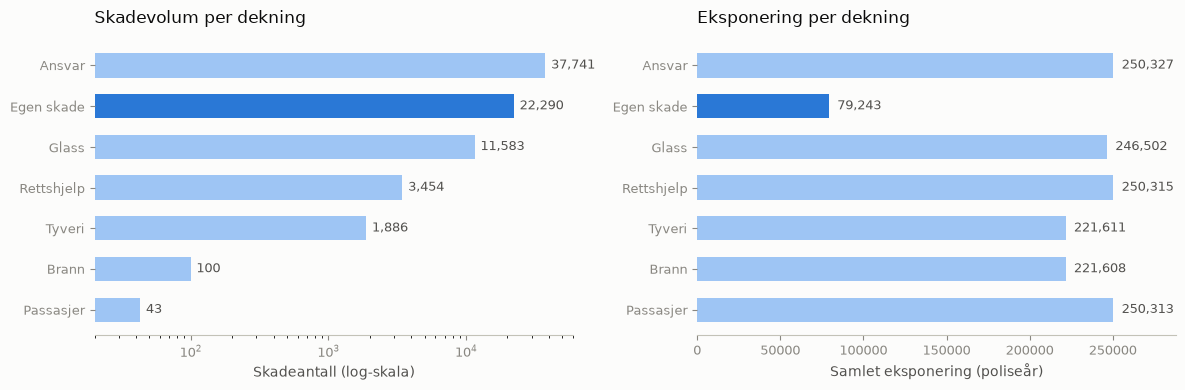

In [15]:
display(plot_response_volume(pre_split["response_summary"]))

In [16]:
display(pre_split["response_summary"])

,dekning,poliseår_i_risiko,samlet_eksponering,skadeantall,poliseår_med_skade,poliseår_med_flere_skader,samlet_incurred,skaderader_med_null_incurred,modellomfang
0,Ansvar,354092,250326.90,37741,30707,6004,47350877.23,9971,Selvstendig modellering aktuell
1,Egen skade,109338,79243.05,22290,12535,4194,18646804.98,11,Selvstendig modellering aktuell
2,Tyveri,311960,221610.80,1886,1845,41,1597689.70,0,Enklere modell eller sammenslåing
3,Brann,311957,221608.29,100,100,0,270157.59,1,For lite for selvstendig detaljmodell
4,Glass,348301,246501.91,11583,11152,413,4460227.80,2,Selvstendig modellering aktuell
5,Rettshjelp,354073,250315.30,3454,3395,59,1176874.22,51,Enklere modell eller sammenslåing
6,Passasjer,354071,250313.29,43,43,0,358890.65,0,For lite for selvstendig detaljmodell


## 11. Avgrensning til egen-skadedekning

Basert på dekningsmatrisen (seksjon 9) og responsvolumet (seksjon 10)
avgrenses videre analyse til poliseår med positiv `property_damage_premium`
og positiv `total_exposure`. Premien brukes bare til å identifisere at
dekningen er aktiv, ikke som prediktor. Denne avgrensningen gir en tydelig
risikopopulasjon med tilstrekkelig skadevolum for både frekvens- og
severitymodellering. Naturlige utvidelser er å gjenta samme analyse separat
for de øvrige dekningene.

**Hvor koden ligger.** Avgrensningen gjøres av `select_own_damage_scope` i
`src/model_data.py`. Funksjonen filtrerer på nøyaktig regelen over:
`property_damage_premium > 0` og `total_exposure > 0`. Den ligger i et felles
script slik at modelleringsnotebooken `glm_pricing_models` bruker samme
populasjon uten å kopiere koden. Selve beslutningen og begrunnelsen står her.

In [17]:
df = select_own_damage_scope(data)
scope_summary, scope_exceptions = build_own_damage_scope_validation(df)
display(scope_summary)
display(scope_exceptions)
assert df["property_damage_premium"].gt(0).all()
assert df["total_exposure"].gt(0).all()

,policy_type,poliseår,poliseår_med_positiv_eksponering,poliseår_i_modell,skadeantall_i_modell,andel_av_positive_eksponeringer_prosent
0,CC,1978,1978,1978,309,100.0
1,COMP_E,91181,91181,91181,12102,100.0
2,COMP_N,16179,16179,16179,9879,100.0


,insured_id,year,policy_type,policy_status,total_exposure,property_damage_premium,property_claims,property_incurred


In [18]:
# Som vi ser inneholder kun datasettet de forventede polisetypene etter avgrensningen.
df["policy_type"].unique()

['COMP_E', 'COMP_N', 'CC']
Categories (5, str): ['TP', 'TPG', 'CC', 'COMP_E', 'COMP_N']

Valideringen viser hvordan avgrensningen fordeler seg på produkttype og lister
alle skader som faller utenfor regelen. Slike unntak beholdes som dokumenterte
datavvik, men brukes ikke til å definere dekning fordi det ville innebære at
skadeutfallet bestemmer modellpopulasjonen.

## 12. Train/test-splitt

Splitten er tidsbasert (out-of-time), ikke en tilfeldig radsplitt: 2022 og
2023 slås sammen til en train/CV-pool, mens 2024 holdes urørt som endelig
test. Dette speiler faktisk bruk av en prisingsmodell — fit på historikk,
prises på neste års fornyelser — og fanger opp temporal drift (f.eks.
skadeinflasjon) som en tilfeldig splitt ikke ville avslørt.

Hyperparametertuning skjer med `GroupKFold` på `insured_id` innad i
train/CV-pool, ikke vanlig radbasert k-fold: samme polise kan opptre i både
2022 og 2023, og uten gruppering kunne de to poliseårene til samme polise
havnet i ulike foldere og gitt et for optimistisk CV-estimat. Testsettet
rører vi ikke igjen før endelig evaluering. All videre deskriptiv/
eksplorativ analyse av prediktorer bør fra nå av kun bruke `train_pool`.

**Hvor koden ligger.** Tidssplitten gjøres av `split_by_year` i
`src/model_data.py`, med `TRAIN_YEARS = (2022, 2023)` og `TEST_YEAR = 2024`
definert samme sted. Splitten er en ren filtrering på `year` og bruker ingen
skadeutfall. `GroupKFold` under er bare en strukturell kontroll av at
gruppering på `insured_id` fungerer. Foldene som faktisk brukes til
modellvalg (med stokking og fast seed, pluss en tidsfold 2022 → 2023)
defineres i `glm_pricing_models`, fordi CV-designet er en del av
modelleringen.

In [19]:
def check_group_disjoint_folds(train_pool, cv, groups):
    """Bekreft at ingen insured_id opptrer i både train- og valideringsfold."""
    for fold, (train_idx, val_idx) in enumerate(cv.split(train_pool, groups=groups)):
        train_fold_ids = set(groups.iloc[train_idx])
        val_fold_ids = set(groups.iloc[val_idx])
        if train_fold_ids & val_fold_ids:
            raise ValueError(
                f"Fold {fold} har overlappende insured_id mellom train og val."
            )
    return True

In [20]:
train_pool, test = split_by_year(df, TRAIN_YEARS, TEST_YEAR)
cv = GroupKFold(n_splits=5)
split_summary, overlap_summary = build_split_summary(train_pool, test)
display(split_summary)
display(overlap_summary)

,sett,poliseår,unike_poliser,eksponering,skadeantall,andel_poliseår_med_skade_prosent,incurred
0,Train/CV-pool (2022-2023),56084,37727,37904.44,10126,10.30,8803785.41
1,Test (2024),53254,53254,41338.61,12164,12.69,9843019.58


,Verdi
unike_poliser_train_pool,37727.00
unike_poliser_test,53254.00
poliser_i_begge,33503.00
andel_av_test_som_er_videreført_prosent,62.91


Overlappen mellom train/CV-pool og test er forventet og ønsket her — det
er videreførte poliser som prises på nytt i 2024, ikke lekkasje. Til slutt
bekreftes det at `GroupKFold` faktisk holder `insured_id` adskilt mellom
train- og valideringsfold.

In [21]:
check_group_disjoint_folds(train_pool, cv, train_pool["insured_id"])

True

## 12.1 Policy status: diagnostikk, ikke prediktor

`policy_status` er `A` for aktiv og `C` for kansellert/opphørt. Tabellen og
plottet er begrenset til train-poolen og viser **rå, eksponeringsvektede**
forskjeller. Kansellerte poliser har nesten tre ganger så høy frekvens og ren
premie som aktive, mens severity er nær lik. Forskjellen i ren premie drives
dermed av frekvens, ikke skadebeløp per skade.

Samtidig har alle kansellerte poliseår delårseksponering. Dette kan være
seleksjon knyttet til opphør i løpet av året, og statusen kan også være kjent
først etter prisingsdatoen eller påvirket av en skade. `policy_status` brukes
derfor kun som diagnostikk og holdes utenfor modellene. Før en eventuell
revurdering må tidspunktet statusen fastsettes på dokumenteres.

,status,poliseår,eksponering,andel_delårseksponering_prosent,frekvens,severity,ren_premie
0,A,52705,36007.44,63.78,0.24,871.04,212.39
1,C,3379,1897.01,100.00,0.71,858.88,609.41


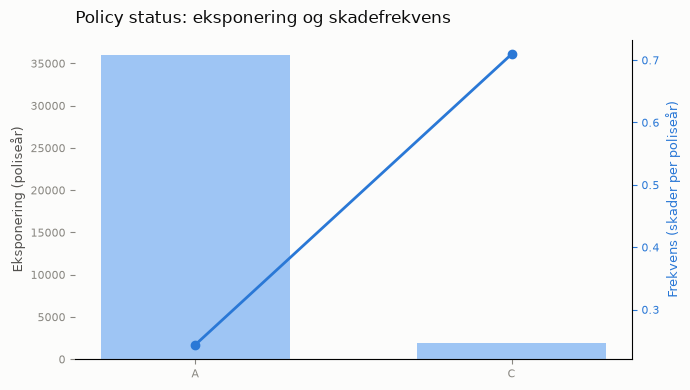

In [22]:
policy_status_one_way = build_categorical_one_way(train_pool, "policy_status")
policy_status_short_exposure = (
    train_pool.assign(delår=train_pool["total_exposure"].lt(1))
    .groupby("policy_status", observed=True)["delår"]
    .mean()
    .mul(100)
    .rename("andel_delårseksponering_prosent")
    .reset_index()
    .rename(columns={"policy_status": "nivå"})
)
policy_status_summary = (
    policy_status_one_way.merge(policy_status_short_exposure, on="nivå", how="left")
    .rename(columns={"nivå": "status"})
    .loc[
        :,
        [
            "status",
            "poliseår",
            "eksponering",
            "andel_delårseksponering_prosent",
            "frekvens",
            "severity",
            "ren_premie",
        ],
    ]
    .round(2)
)
display(policy_status_summary)
display(
    plot_one_way(
        policy_status_one_way,
        "Policy status: eksponering og skadefrekvens",
        rate_column="frekvens",
        rate_label="Frekvens (skader per poliseår)",
    )
)

# Deskriptiv analyse av modellvariablene

Alt fra dette punktet bruker **kun `train_pool`** (2022-2023), i tråd med
beslutningen i seksjon 12. Formålet er å forstå frekvens, severity og ren
premie for egen skade, og å identifisere hvilke prediktorer som ser ut til
å ha forklaringskraft, før modellspesifikasjon. `test` (2024) holdes urørt.

## 13. Frekvens: fordeling og overspredning

Fordelingen av `property_claims` viser hvor konsentrert skadeutfallet er
(de fleste poliseår har 0 skader). Spredningsforholdet (varians/snitt)
avgjør om Poisson (forhold ≈ 1) er en rimelig antakelse for frekvensmodellen,
eller om overspredning krever negativ binomial.

,skadeantall,poliseår,andel_poliseår_prosent,eksponering
0,0,50306,89.70,33042.92
1,1,3892,6.94,3207.93
2,2,799,1.42,698.41
3,3+,1087,1.94,955.18


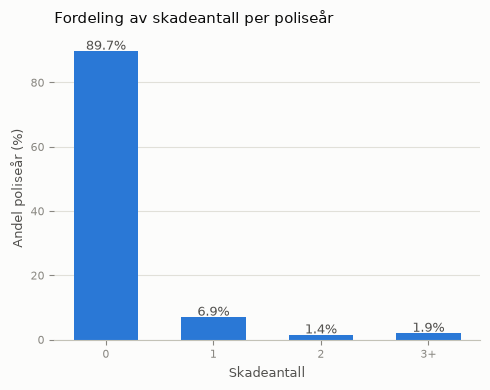

In [23]:
claim_distribution = build_claim_count_distribution(train_pool)
display(claim_distribution)
display(plot_claim_count_distribution(claim_distribution))

In [24]:
display(build_overdispersion_summary(train_pool))

,Verdi
gjennomsnitt,0.1806
varians,0.4679
spredningsforhold_var_over_snitt,2.5916
andel_poliseår_uten_skade_prosent,89.6976


## Implikasjoner:
Variansen avviker betydelig fra gjennomsnittet og stemmer ikke overens med poisson fordeling. Undersøker videre om negativ binomialfordeling er mer egnet.

## 14. Severity

Severity (`property_incurred / property_claims`, kun poliseår med skade)
er beregnet per poliseår, ikke per skademelding — ved flere skader i samme
poliseår er tallet et gjennomsnitt. Gamma og lognormal sammenlignes med MLE
og AIC på den strengt positive, **uvektede** delen; dette er en deskriptiv
density-fit, ikke et endelig severitymodellvalg. Null-severity vises
eksplisitt og inngår ikke i den kontinuerlige fitten. For
fordelingsdiagnostikken behandles beløp med absoluttverdi ≤ 0,01 som numerisk
null (én cent, gitt kildens EUR-presentasjon); rådata og sammendrag endres
ikke. En eventuell
claim-count-vektet fit ville besvare et annet spørsmål enn fordelingen av
aggregerte poliseår og overlates til senere modellering.

,Verdi
n_skaderader,5778.00
andel_med_severity_null_prosent,0.12
gjennomsnitt,1059.07
median,616.50
std,1579.18
p90,2108.22
p99,7972.73
maks,27332.54
skjevhet,6.17


,fordeling,parameter_1,parameter_1_navn,parameter_2,parameter_2_navn,log_likelihood,aic,valgt_best_aic
0,Gamma,1.126,shape,941.699,scale,-45934.942,91873.883,False
1,Lognormal,1.011,sigma,639.781,scale = exp(mu),-45524.241,91052.481,True


,Verdi
Numerisk nulltoleranse i fordelingsdiagnostikk,1.000000e-02
Eksakte null-severity,7.000000e+00
Nærnuller klassifisert som null kun i diagnostikk,2.000000e+00
Minste substantielle positive severity,1.150000e-02
"Normalitetstest for log(severity), statistikk",8.027305e+02
"Normalitetstest for log(severity), p-verdi",4.889810e-175


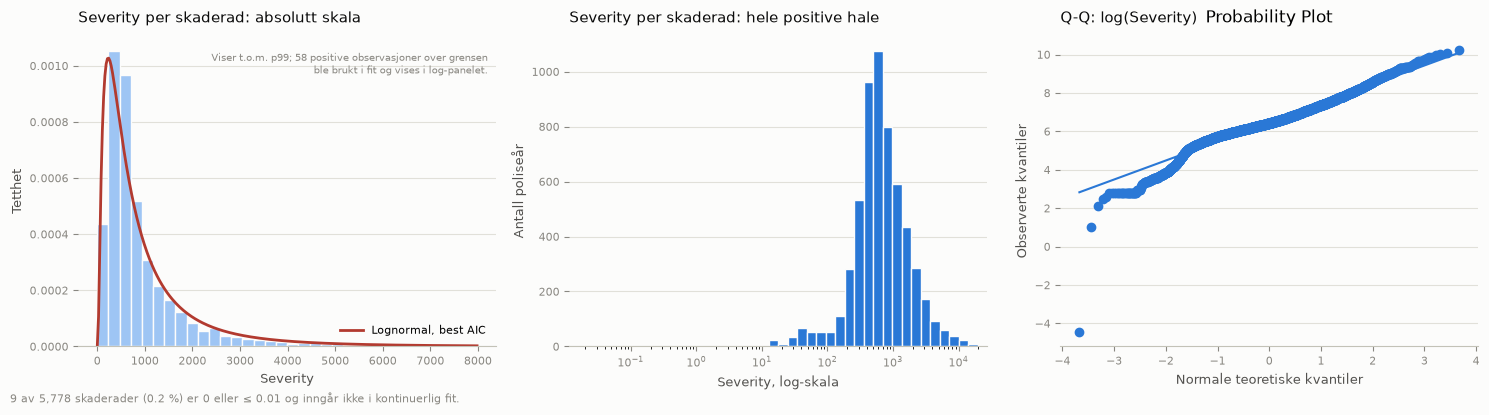

In [25]:
display(build_severity_summary(train_pool))
severity_fit = build_severity_distribution_fit(train_pool)
display(severity_fit)
display(
    pd.Series(
        {
            "Numerisk nulltoleranse i fordelingsdiagnostikk": severity_fit.attrs[
                "zero_tolerance"
            ],
            "Eksakte null-severity": severity_fit.attrs["exact_zero_count"],
            "Nærnuller klassifisert som null kun i diagnostikk": severity_fit.attrs[
                "near_zero_count"
            ],
            "Minste substantielle positive severity": (
                train_pool.loc[train_pool["property_claims"].gt(0), "property_incurred"]
                .div(
                    train_pool.loc[
                        train_pool["property_claims"].gt(0), "property_claims"
                    ]
                )
                .loc[lambda values: values.gt(severity_fit.attrs["zero_tolerance"])]
                .min()
            ),
            "Normalitetstest for log(severity), statistikk": severity_fit.attrs[
                "normality_stat"
            ],
            "Normalitetstest for log(severity), p-verdi": severity_fit.attrs[
                "normality_pvalue"
            ],
        },
        name="Verdi",
    ).to_frame()
)
display(plot_severity_distribution(train_pool, severity_fit))

Q-Q-panelet er relevant bare dersom lognormalfordeling vurderes. En Gamma GLM
med log-link antar **ikke** lognormalitet. Formelle normalitetstester ved stort
n avviser ofte små avvik og skal ikke velge modell alene; Q-Q, haletilpasning
og senere out-of-sample deviance/kalibrering veier tyngre.

Lognormal fordelingen bommer fremdeles betydelig i halen. Dette motiverer en vurdering av å modellere storskader og

## 15. Ren premie (severity × frekvens)

Ren premie er `property_incurred / total_exposure` per poliseår — kombinerer
frekvens og severity, og er størrelsen en Tweedie-modell til slutt skal
predikere. Den har punktmasse i null (ingen skade) og en kontinuerlig,
skjev hale for poliseår med kostnad. Gamma og lognormal sammenlignes kun for
den positive delen med MLE/AIC; ingen observasjoner slettes, og absolutt-
panelet begrenses transparent til p99 bare for lesbarhet.

,Verdi
andel_poliseår_uten_skadekostnad_prosent,89.71
gjennomsnitt_alle,243.57
gjennomsnitt_gitt_positiv,2367.09
median_gitt_positiv,1272.52
p90_gitt_positiv,4399.58
p99_gitt_positiv,16254.93
maks,1185094.17


,fordeling,parameter_1,parameter_1_navn,parameter_2,parameter_2_navn,log_likelihood,aic,valgt_best_aic
0,Gamma,0.834,shape,2839.629,scale,-50526.031,101056.062,False
1,Lognormal,1.174,sigma,1166.639,scale = exp(mu),-49849.901,99703.801,True


,Verdi
Numerisk nulltoleranse i fordelingsdiagnostikk,1.000000e-02
Eksakte nuller i ren premie,5.031300e+04
Nærnuller klassifisert som null kun i diagnostikk,2.000000e+00
Minste substantielle positive ren premie,1.150000e-02
"Normalitetstest for log(positiv ren premie), statistikk",6.980656e+02
"Normalitetstest for log(positiv ren premie), p-verdi",2.612060e-152


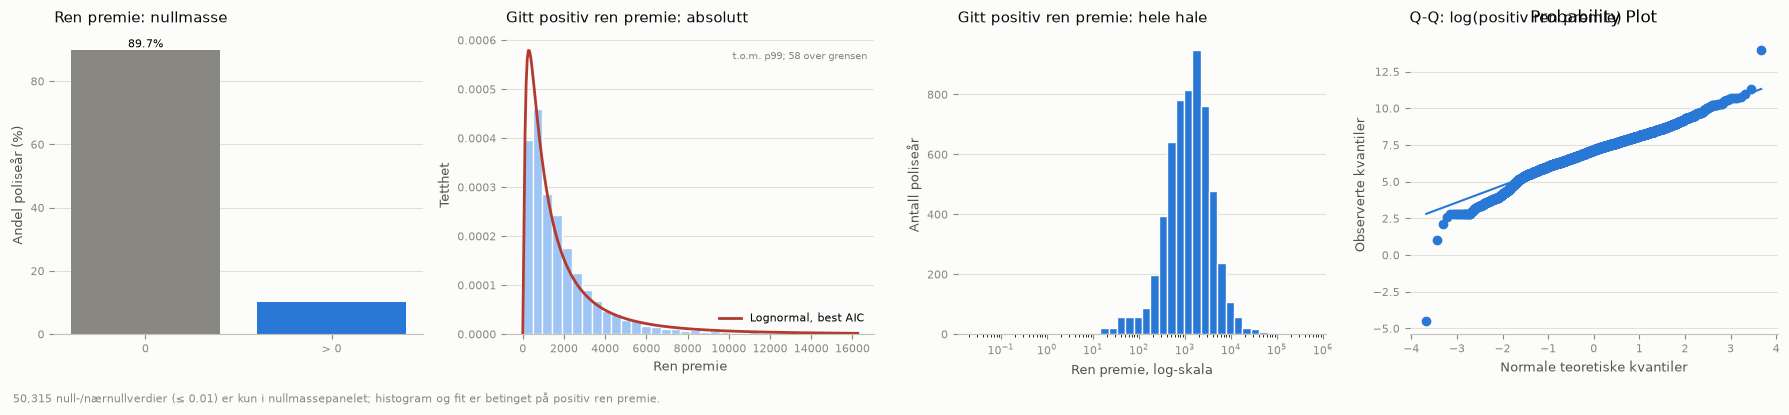

In [26]:
display(build_pure_premium_summary(train_pool))
pure_premium_fit = build_pure_premium_distribution_fit(train_pool)
display(pure_premium_fit)
display(
    pd.Series(
        {
            "Numerisk nulltoleranse i fordelingsdiagnostikk": pure_premium_fit.attrs[
                "zero_tolerance"
            ],
            "Eksakte nuller i ren premie": pure_premium_fit.attrs["exact_zero_count"],
            "Nærnuller klassifisert som null kun i diagnostikk": pure_premium_fit.attrs[
                "near_zero_count"
            ],
            "Minste substantielle positive ren premie": (
                train_pool["property_incurred"] / train_pool["total_exposure"]
            )
            .loc[lambda values: values.gt(pure_premium_fit.attrs["zero_tolerance"])]
            .min(),
            "Normalitetstest for log(positiv ren premie), statistikk": pure_premium_fit.attrs[
                "normality_stat"
            ],
            "Normalitetstest for log(positiv ren premie), p-verdi": pure_premium_fit.attrs[
                "normality_pvalue"
            ],
        },
        name="Verdi",
    ).to_frame()
)
display(plot_pure_premium_distribution(train_pool, pure_premium_fit))

Den samlede renpremiefordelingen har punktmasse i null og er aktuarielt mer
forenlig med compound Poisson–Gamma/Tweedie enn én kontinuerlig Gamma- eller
lognormalfordeling. AIC-valget over beskriver derfor bare den betinget
positive delen og erstatter ikke senere out-of-sample modellkontroll.

## 16. Tidstrend i train_pool (2022 vs. 2023)

Kun to år tilgjengelig i train_pool, men en sjekk av om frekvens/severity
endrer seg mellom dem er relevant for om `year` bør inn som prediktor/offset,
eller om skadeinflasjon bør vurderes separat.

,year,eksponering,skadeantall,frekvens,incurred,severity,ren_premie
0,2022,12173.9808,2864,0.2353,2.678608e+06,935.2682,220.0273
1,2023,25730.4630,7262,0.2822,6.125177e+06,843.456,238.0516


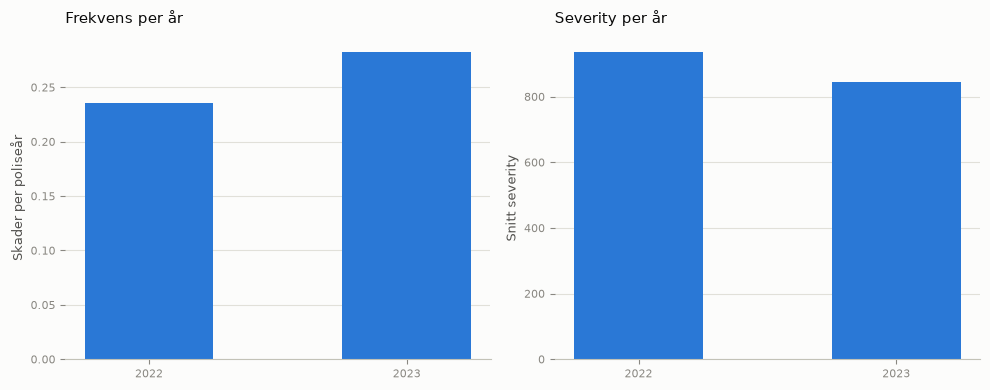

In [27]:
year_trend = build_year_trend_summary(train_pool)
display(year_trend)
display(plot_year_trend(year_trend))

## 17. Transparente transformasjoner og aldersdiagnostikk

De publiserte kildene er selvmotsigende: variabelarket omtaler
`age_driving_licence` som kalenderår, mens observerte verdier og de
longitudinelle mønstrene er uforenlige med det. Arbeidshypotesen her er at
feltet er **alder ved førerkorterverv**. Da blir
`driving_experience_years = driver_age - age_driving_licence`, og
`vehicle_age` er nesten det samme målet. Dette taler for at `vehicle_age`
feilaktig representerer førerkortansiennitet, ikke reell kjøretøyalder.

Hypotesen er svært godt støttet av data, men ikke endelig bevist: publisert
transformasjonskode mangler. Reell kjøretøyalder behandles derfor som
utilgjengelig. `vehicle_age` brukes bare i diagnosen nedenfor og aldri sammen
med den utledede erfaringen som modellprediktor.

In [28]:
display(
    source_dictionary_raw.loc[
        source_dictionary_raw["Variables"].isin(
            ["driver_age", "age_driving_licence", "vehicle_age"]
        )
    ]
)
display(
    variable_dictionary.loc[
        variable_dictionary["variable"].isin(
            ["driver_age", "age_driving_licence", "vehicle_age"]
        )
    ]
)

,Variables,Description,Group
21,driver_age,"Age of the main driver associated with the policy, measured in years.",Driver and vehicle characteristics
22,vehicle_age,"Age of the insured vehicle, also measured in years.",Driver and vehicle characteristics
23,age_driving_licence,Year in which the insured obtained the driving licence.,Driver and vehicle characteristics


,variable,group,description,unit_or_codes,analysis_role,clean_dtype,missing_allowed
7,driver_age,Fører og kjøretøy,Alder på hovedføreren som er registrert på polisen.,Hele år,Numerisk risikofaktor,Int16,Nei
8,vehicle_age,Fører og kjøretøy,"Kildens dokumentasjon kaller feltet kjøretøyalder, men dataene er nesten identiske med utledet førerkortansiennitet....",Hele år ifølge kilden; observert tolkning er førerkortansiennitet,Uavklart diagnostisk felt,Int16,Ja
9,age_driving_licence,Fører og kjøretøy,"Kildedokumentasjonen er selvmotsigende. Dataene indikerer svært sterkt at feltet er alder ved førerkorterverv, ikke ...",Alder i hele år (observert tolkning/arbeidshypotese),Numerisk risikofaktor,Int16,Ja


Transformasjonene under er forhåndsbestemte og bruker ingen skadeutfall.
Merke-poolingen læres utelukkende fra eksponering i `train_pool`: nivåer med
minst 500 eksponeringsår beholdes, mens øvrige og hittil usette merker får
`OTHER`. Den samme regelen brukes på testsettet. Eksponering er bare vekt/
offset i rateberegningene, aldri en prediktor. `performance_hp_per_tonne =
1000 / power_to_weight_ratio` snur kildens kg-per-hk-mål: høyere verdi betyr
flere hestekrefter per tonn og dermed høyere ytelse. Bare positive inputverdier
transformeres; manglende input forblir manglende.

**Hvor koden ligger.** Begge stegene ligger i `src/model_data.py`, slik at
modelleringsnotebooken får identiske prediktorer:

- `learn_retained_brands(train_pool, min_exposure=500.0)` summerer
  `total_exposure` per `vehicle_brand` i `train_pool` og returnerer merkene over
  grensen sammen med eksponeringen per merke.
- `add_transparent_predictors(frame, retained_brands)` lager
  `driving_experience_years`, `log_vehicle_value`, `performance_hp_per_tonne`
  og `vehicle_brand_pooled` etter reglene over.

Kontrollene under ligger fortsatt i notebooken og bekrefter at resultatet
følger reglene.

In [29]:
retained_brands, brand_exposure_train = learn_retained_brands(
    train_pool, min_exposure=BRAND_MIN_EXPOSURE
)
train_pool = add_transparent_predictors(train_pool, retained_brands)
test = add_transparent_predictors(test, retained_brands)
assert train_pool["driving_experience_years"].ge(0).all()
assert test["vehicle_brand_pooled"].isin([*retained_brands, "OTHER"]).all()
assert (
    train_pool.loc[train_pool["power_to_weight_ratio"].notna(), "power_to_weight_ratio"]
    .gt(0)
    .all()
)
assert (
    train_pool["performance_hp_per_tonne"]
    .isna()
    .eq(train_pool["power_to_weight_ratio"].isna())
    .all()
)
unseen_test_brands = set(test["vehicle_brand"].astype(str)) - set(
    train_pool["vehicle_brand"].astype(str)
)
assert (
    test.loc[
        test["vehicle_brand"].astype(str).isin(unseen_test_brands),
        "vehicle_brand_pooled",
    ]
    .eq("OTHER")
    .all()
)
feature_summary = pd.Series(
    {
        "Merker beholdt ved minst 500 eksponeringsår": len(retained_brands),
        "Andel train-eksponering i beholdte merker (%)": (
            brand_exposure_train.loc[retained_brands].sum()
            / brand_exposure_train.sum()
            * 100
        ),
        "Testmerker mappet til OTHER": int(
            test["vehicle_brand_pooled"].eq("OTHER").sum()
        ),
        "Usette testmerker mappet til OTHER": len(unseen_test_brands),
    },
    name="Verdi",
).to_frame()
display(feature_summary.round(2))

,Verdi
Merker beholdt ved minst 500 eksponeringsår,17.00
Andel train-eksponering i beholdte merker (%),88.54
Testmerker mappet til OTHER,6498.00
Usette testmerker mappet til OTHER,1.00


,variabel,manglende,manglende_prosent,min,p01,median,p99,maks
0,driver_age,0,0.0,18,27.0,46.0,73.0,85
1,age_driving_licence,1,0.0,4,18.0,20.0,45.0,69
2,vehicle_age,1,0.0,0,4.0,24.0,49.0,60


,Verdi
sammenlignbare_rader,56083.00
residual_lik_null_prosent,93.41
residual_median,0.00
residual_p01,0.00
residual_p99,1.00
residual_min,0.00
residual_maks,41.00


,variabel,sammenlignbare_overganger,uendret_prosent,lik_årsgapp_prosent,fall_prosent
0,driver_age,18357,37.82,62.16,0.02
1,age_driving_licence,18357,84.96,0.58,14.44
2,vehicle_age,18357,37.23,62.66,0.08
3,driving_experience_years,18357,24.25,75.41,0.03


,Verdi
manglende_utledet_erfaring,1
negativ_utledet_erfaring,0
førerkortalder_under_14,3
førerkortalder_over_føreralder,0


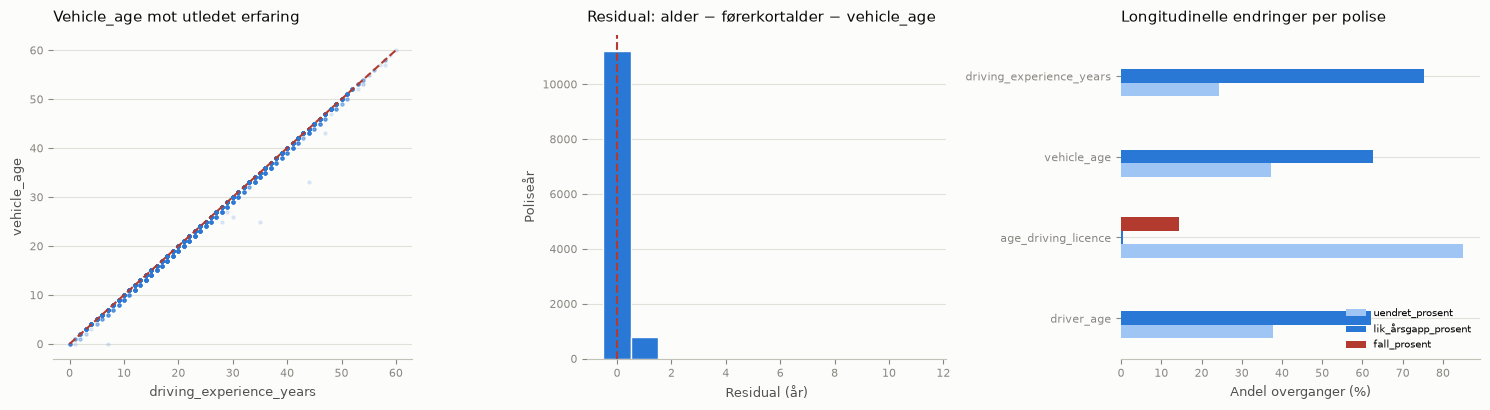

In [30]:
age_diagnostics = build_age_diagnostics(train_pool)
display(age_diagnostics["summary"])
display(age_diagnostics["residual_summary"])
display(age_diagnostics["temporal_changes"])
display(age_diagnostics["plausibility"])
display(plot_age_diagnostics(age_diagnostics))
assert age_diagnostics["plausibility"].loc["negativ_utledet_erfaring", "Verdi"] == 0
assert (
    age_diagnostics["plausibility"].loc["førerkortalder_over_føreralder", "Verdi"] == 0
)

**Konklusjon.** Residualen `driver_age - age_driving_licence - vehicle_age`
er praktisk talt null, og feltene endrer seg i tråd med dette mellom år for
samme polise. Det støtter arbeidshypotesen svært sterkt. Begrensningen er at
dette er en empirisk tolkning av et publisert datasett, ikke en verifisert
datadefinisjon; modellen får derfor ikke en påstått reell kjøretøyalder.

## 18. Bonus_score: foreløpig konklusjon

Den separate [bonusdiagnostikken](bonus_score_analysis.ipynb) tyder på at
`bonus_score` inneholder informasjon utover den eksplisitt observerte
ettårige skadehistorikken. Timingmønsteret er mest konsistent med at scoren
bygger på tidligere års skader, ikke inneværende års skadeutfall. Dette er
ikke et endelig bevis på leakage-fri timing fordi eksakt *as-of*-dato mangler.

`bonus_score` beholdes foreløpig som kategorisk prediktorkandidat, men
vurderes på nytt i modelleringsfasen gjennom leakage-sikker sammenligning av
modeller med/uten bonus og med eksplisitt lagget historikk, bare i train/CV.
Teståret 2024 røres ikke.

## 19. Prediktorer: univariate fordelinger

Rene fordelinger for modellprediktorene, uten skadeutfall. De numeriske
transformasjonene vises i stedet for råvariablene, slik at vi ikke senere
inkluderer rå og transformert variant av samme informasjon samtidig.

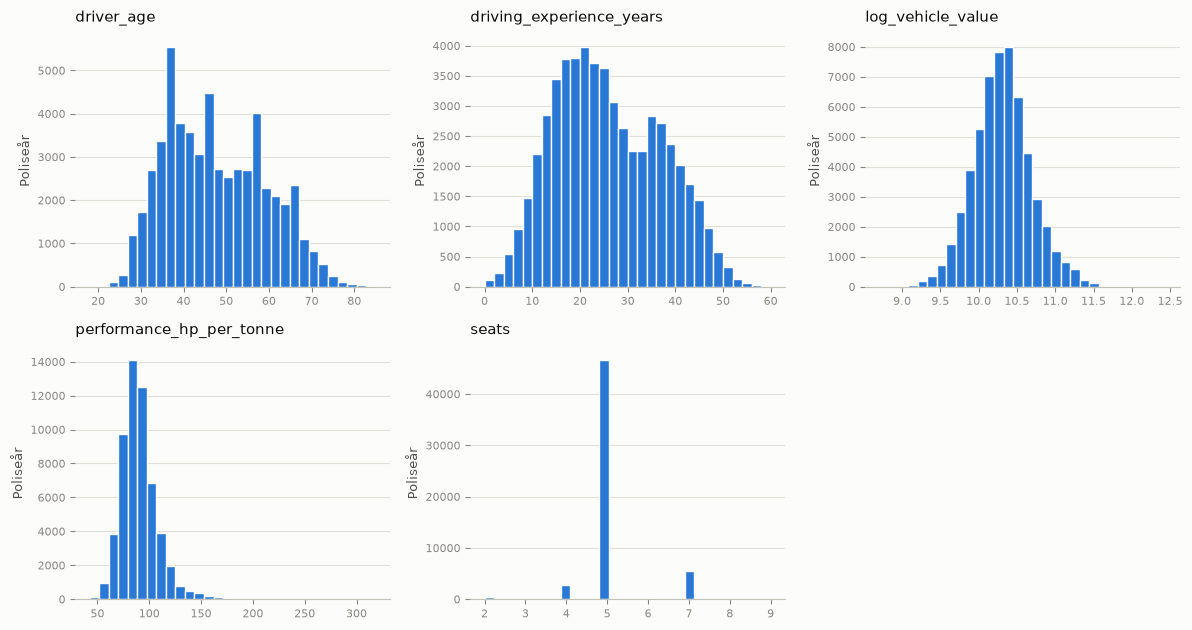

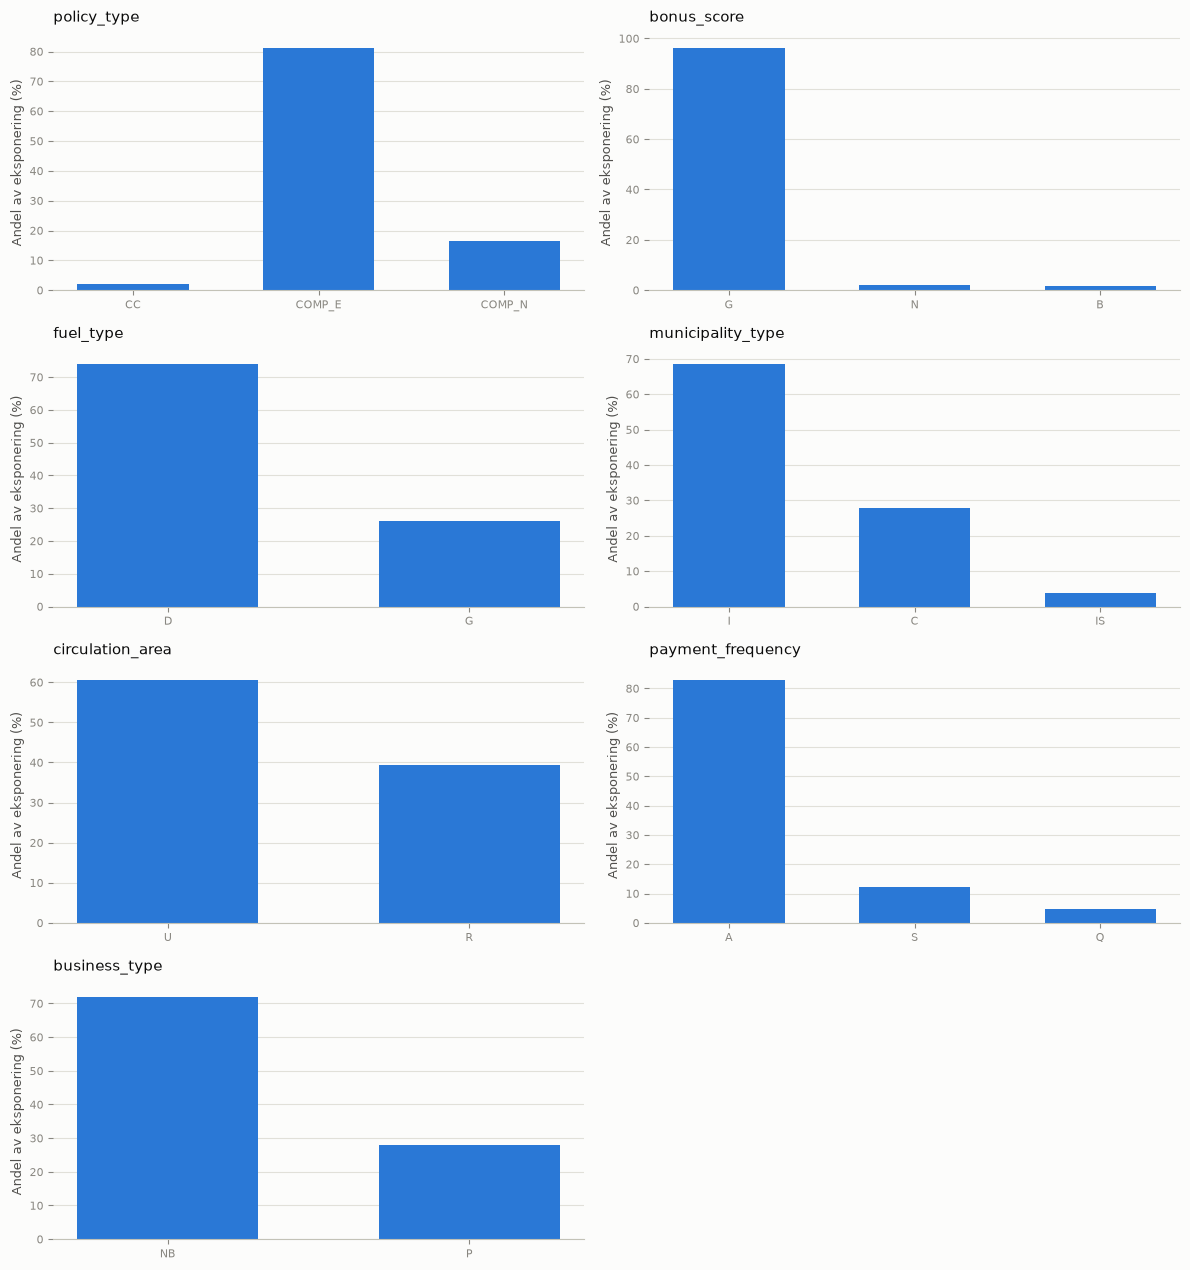

In [31]:
display(plot_numeric_predictor_histograms(train_pool))
display(plot_categorical_predictor_bars(train_pool, columns=CATEGORICAL_VARS[:-1]))

,vehicle_brand,eksponering,andel_eksponering_prosent
0,KIA,768.657534,2.027882
1,VOLVO,798.819178,2.107455
2,HYUNDAI,960.432877,2.533827
3,NISSAN,1503.769863,3.967265
4,SEAT,2107.545205,5.560153
5,TOYOTA,2185.068493,5.764676
6,OPEL,2231.293151,5.886627
7,MERCEDES,2454.010959,6.474204
8,PEUGEOT,2469.698630,6.515591
9,FORD,2481.079452,6.545616


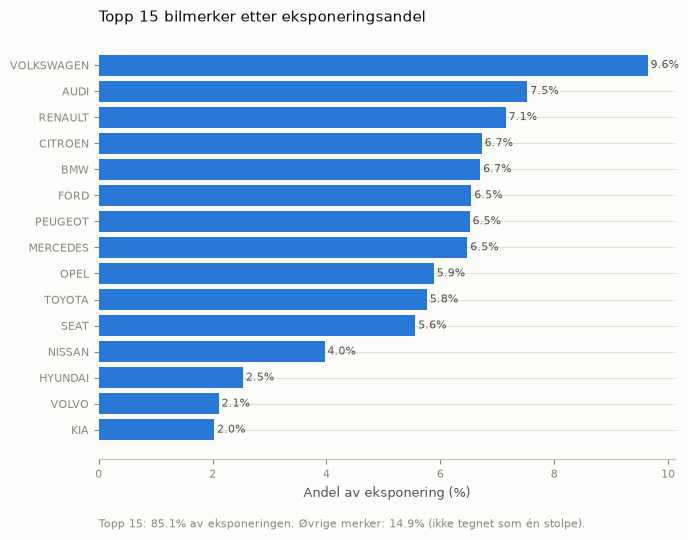

In [32]:
brand_distribution = build_brand_distribution(train_pool)
display(brand_distribution)
display(plot_brand_distribution(brand_distribution))

## 20. Manglende verdier i modellprediktorene

Missingness følges for de transformerte prediktorene som faktisk går videre.
`vehicle_age` er ikke med fordi det er et uavklart diagnostisk felt, ikke en
modellvariabel.

,variabel,gruppe,poliseår,andel_prosent,frekvens,severity
0,driving_experience_years,Ikke manglende,56083,99.9982,0.2671,869.4733
1,driving_experience_years,Manglende,1,0.0018,1.1371,367.7470
2,fuel_type,Ikke manglende,55645,99.2172,0.2667,869.7169
3,fuel_type,Manglende,439,0.7828,0.3255,837.8044
4,log_vehicle_value,Ikke manglende,56051,99.9412,0.2670,869.7444
5,log_vehicle_value,Manglende,33,0.0588,0.6019,620.0057
6,performance_hp_per_tonne,Ikke manglende,56084,100.0000,0.2671,869.4238
7,performance_hp_per_tonne,Manglende,0,0.0000,NaN,NaN


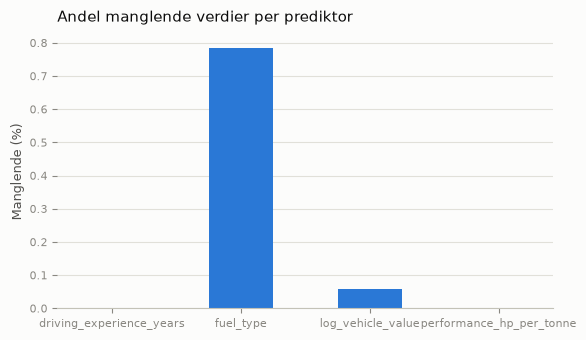

In [33]:
missingness = build_missingness_outcome_comparison(train_pool)
display(missingness)
display(plot_missingness_summary(missingness))

## 21. One-way-analyse: frekvens, severity og ren premie

Oversiktsgridene viser eksponeringsandel og de tre ratene per nivå. Numeriske
variabler er kun delt i faste diagnosebøtter her; senere modellering bør bruke
kontinuerlige ledd eller splines. Stiplet linje er porteføljens rate. For
frekvens vises omtrentlige 95 %-Poissonintervaller; severity og ren premie
vises som punktestimat fordi aggregerte poliseår ikke gir skadeindivid-basert
usikkerhet uten flere modellantakelser.

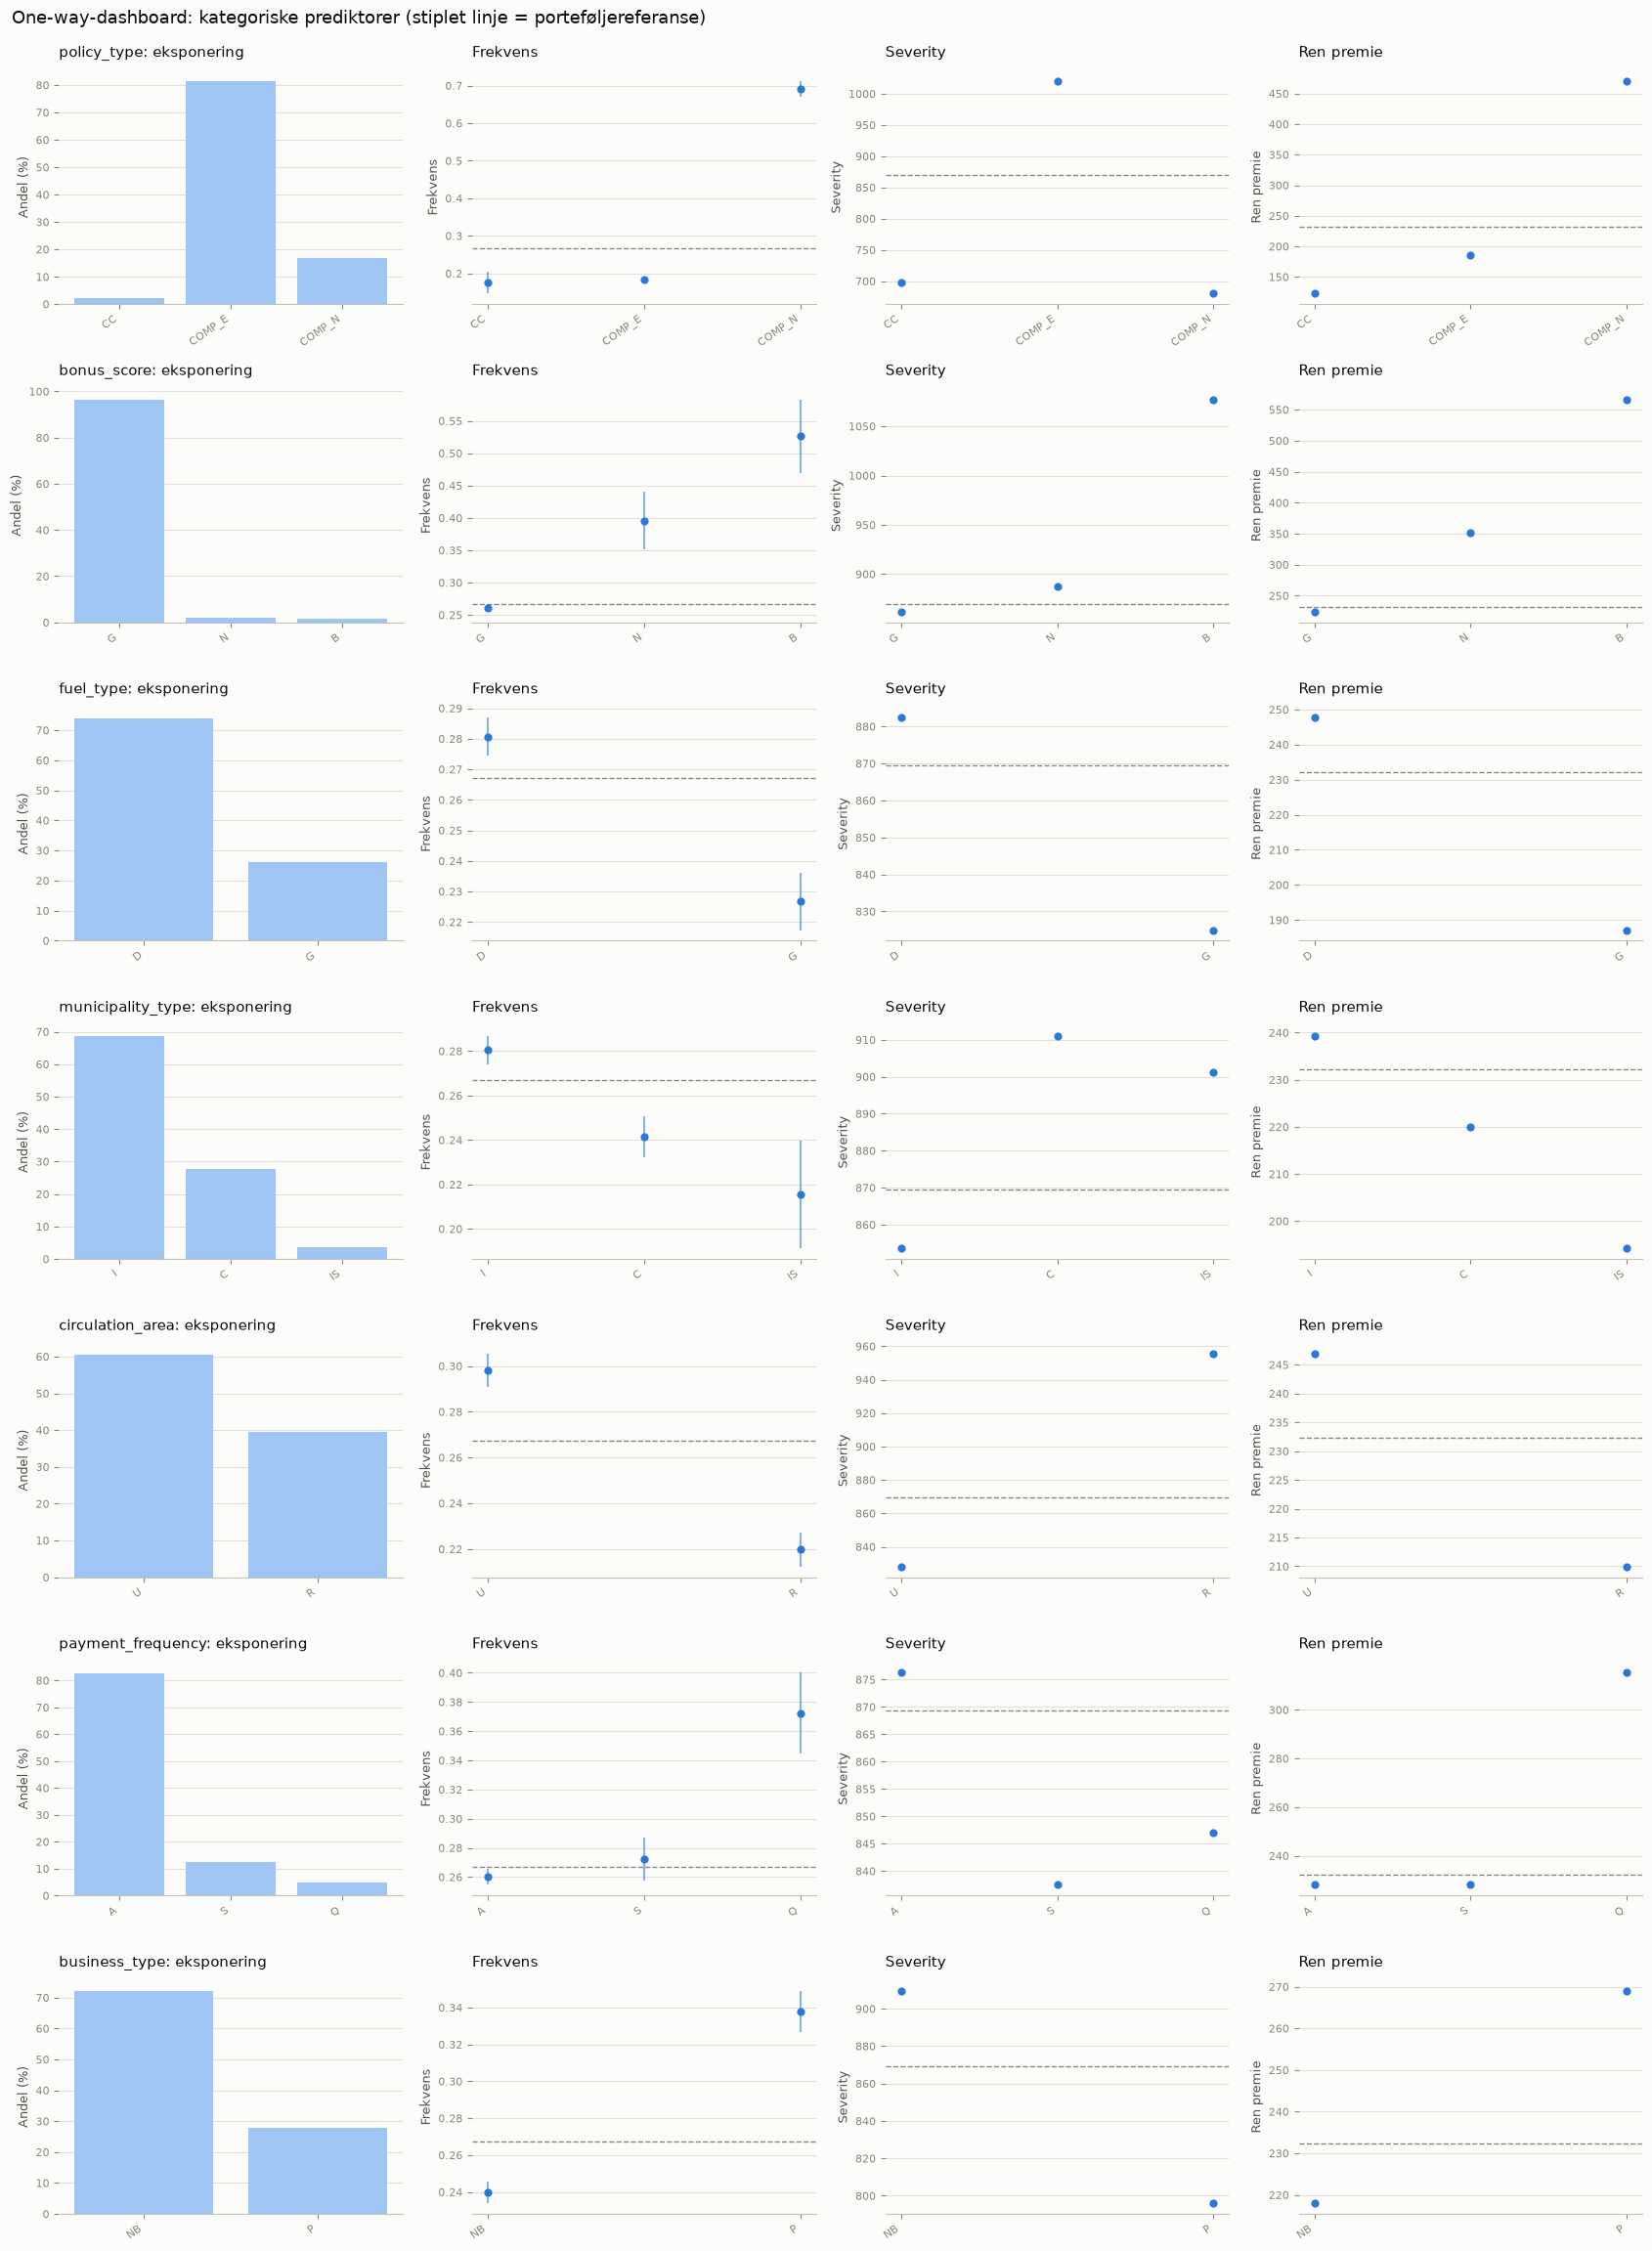

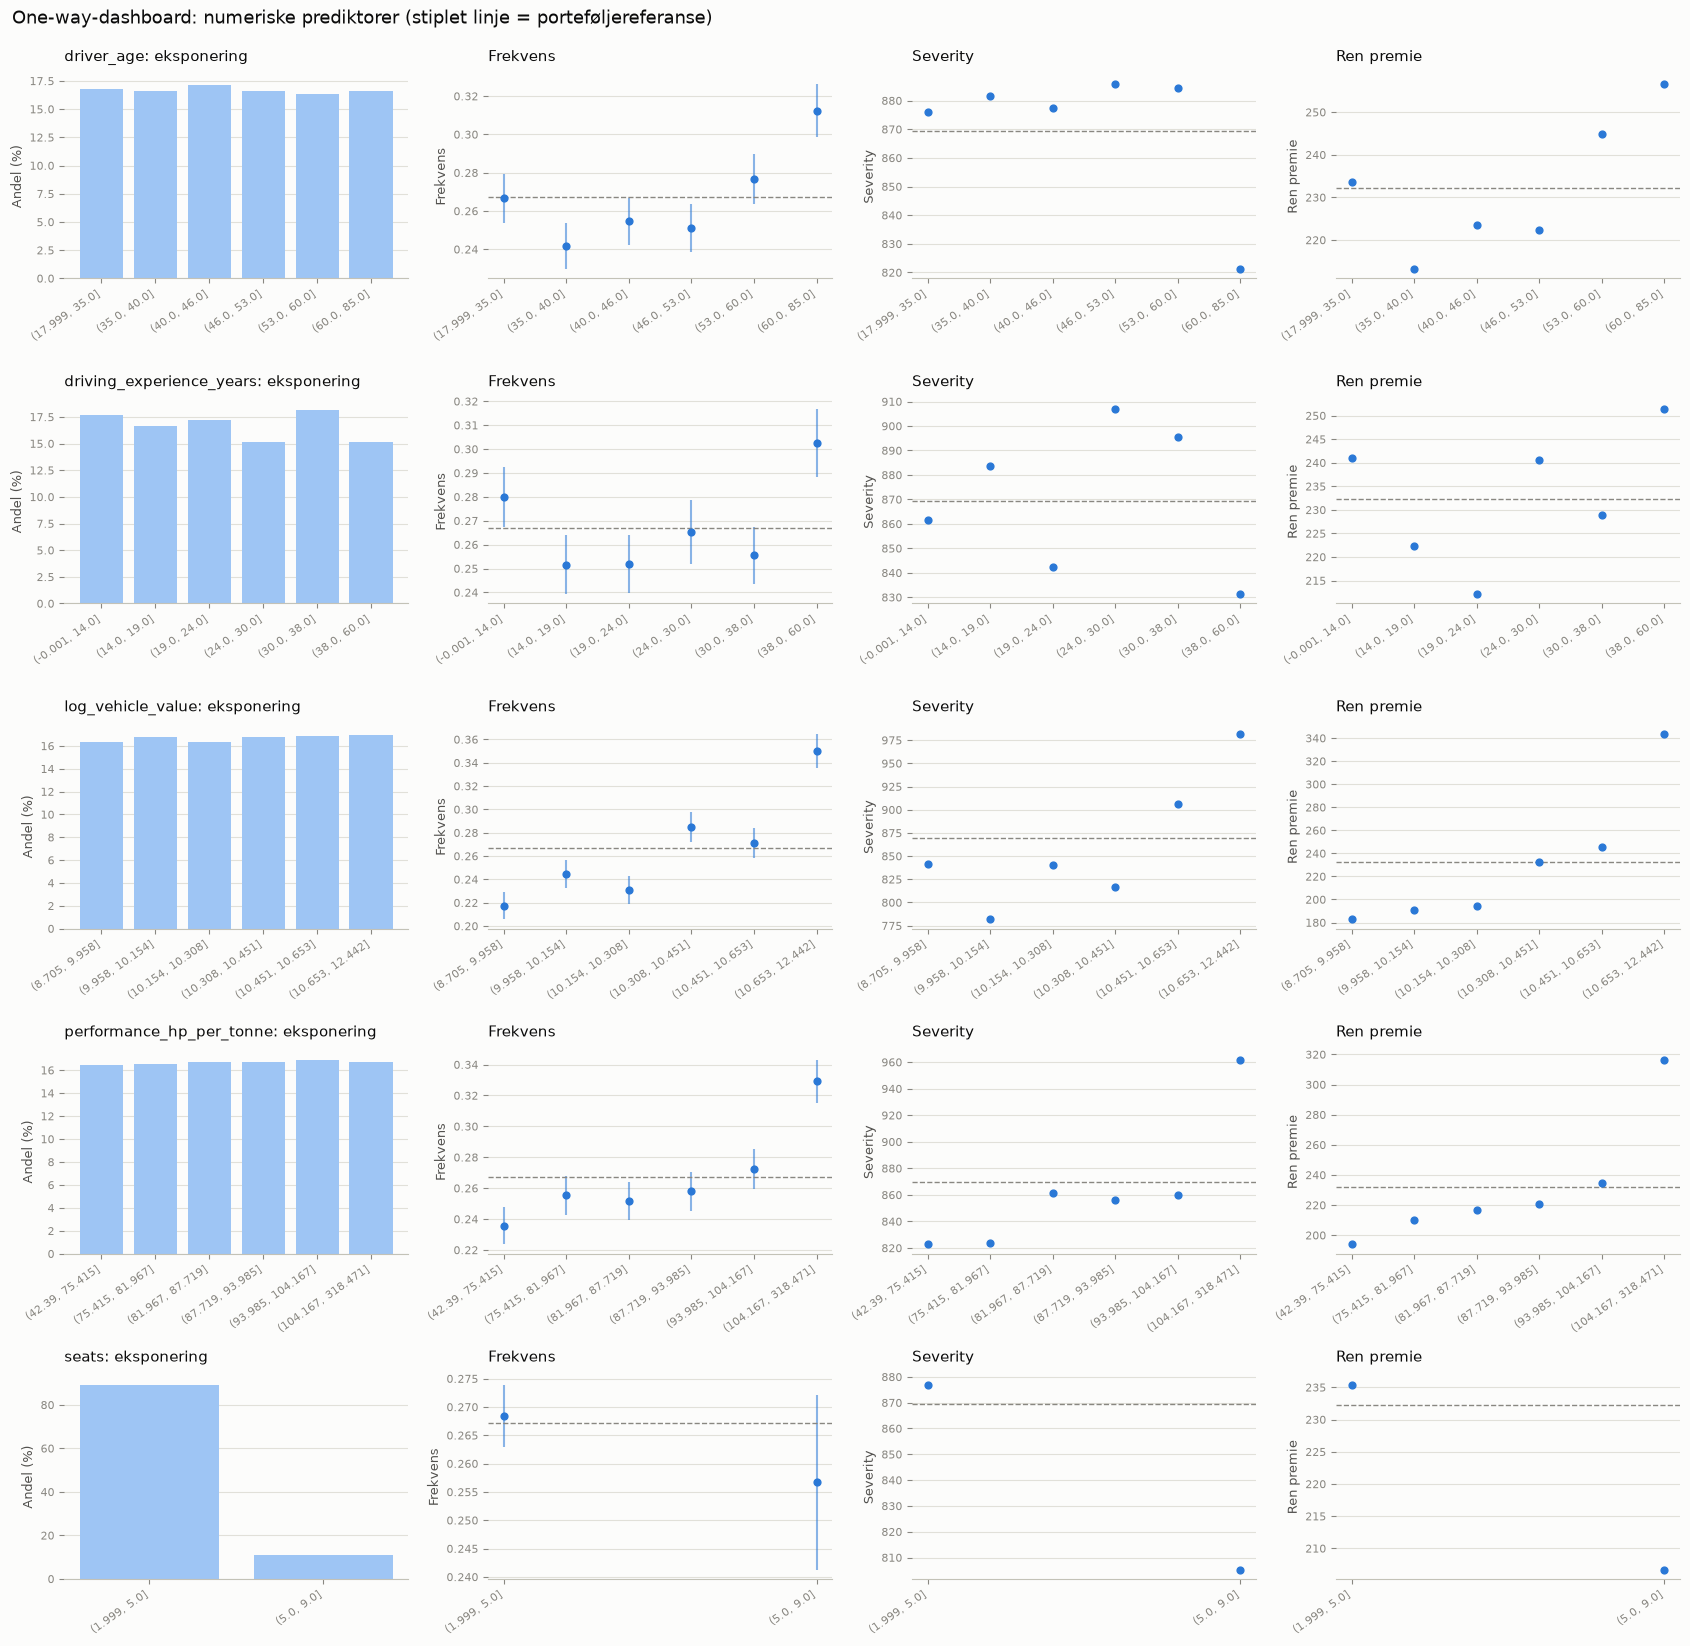

In [34]:
categorical_one_way = {
    column: build_categorical_one_way(train_pool, column)
    for column in CATEGORICAL_VARS[:-1]
}
numeric_one_way = {
    column: build_numeric_one_way(train_pool, column) for column in NUMERIC_VARS
}
display(plot_one_way_grid(categorical_one_way, train_pool, "kategoriske"))
display(plot_one_way_grid(numeric_one_way, train_pool, "numeriske"))

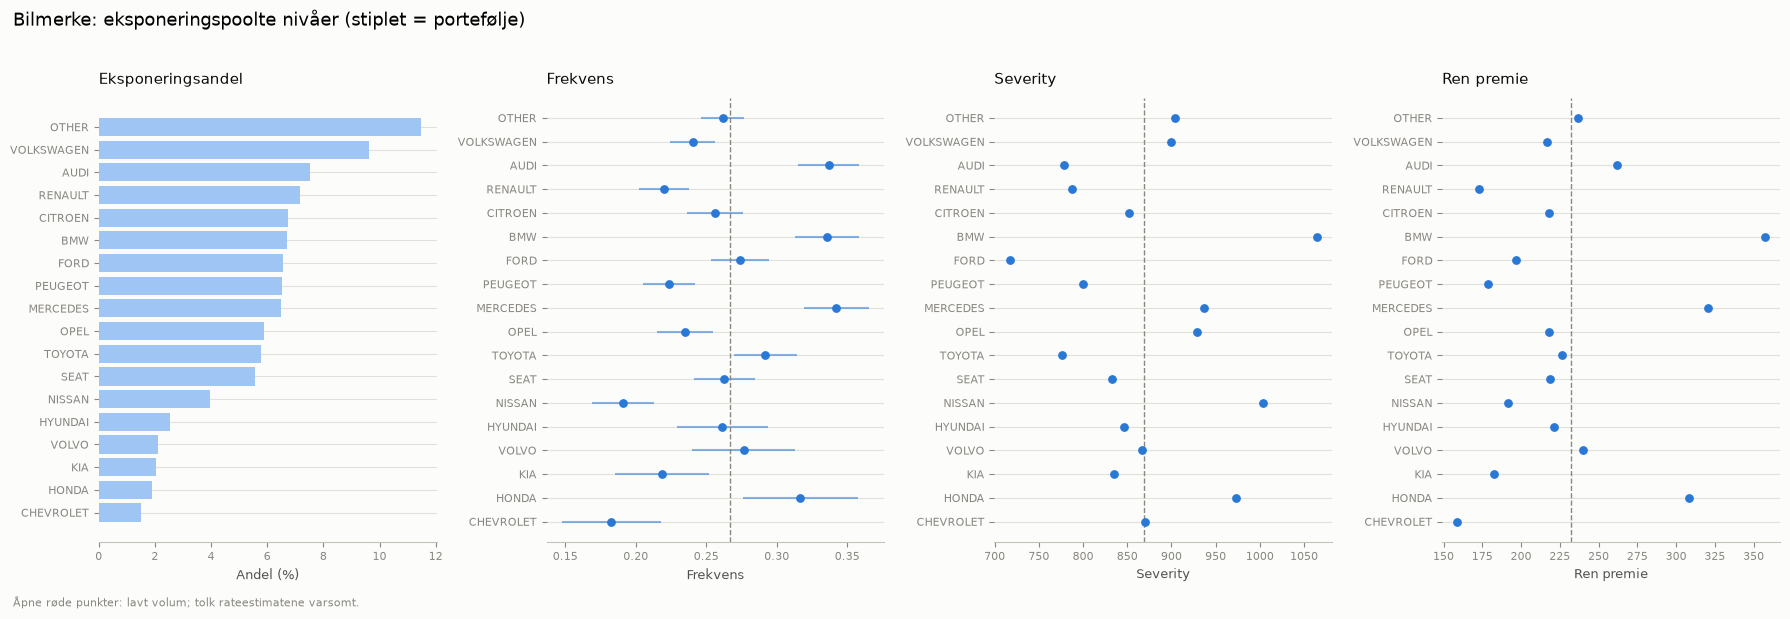

In [35]:
brand_one_way = build_brand_one_way(train_pool)
display(plot_brand_one_way(brand_one_way, train_pool))

## 22. Samvariasjon blant prediktorer

Relevant før GLM: sterkt korrelerte/assosierte prediktorer gir ustabile
koeffisienter. Pearson-korrelasjon for de valgte numeriske prediktorene og
Cramér's V (bias-korrigert) for kategoriske. `vehicle_age` og
`age_driving_licence` er bevisst utelatt fra modellprediktor-listene.

,driver_age,driving_experience_years,log_vehicle_value,performance_hp_per_tonne,seats
driver_age,1.000,0.879,-0.002,0.036,-0.055
driving_experience_years,0.879,1.000,0.064,0.069,-0.036
log_vehicle_value,-0.002,0.064,1.000,0.564,0.162
performance_hp_per_tonne,0.036,0.069,0.564,1.000,-0.171
seats,-0.055,-0.036,0.162,-0.171,1.000


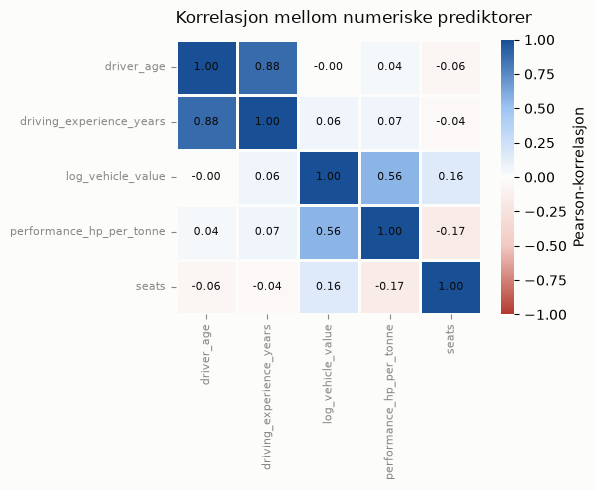

In [36]:
correlation_matrix = build_numeric_correlation(train_pool)
display(correlation_matrix)
display(plot_numeric_correlation_heatmap(correlation_matrix))

,policy_type,bonus_score,fuel_type,municipality_type,circulation_area,payment_frequency,business_type,vehicle_brand_pooled
policy_type,1.000,0.069,0.033,0.061,0.092,0.010,0.097,0.039
bonus_score,0.069,1.000,0.030,0.012,0.043,0.021,0.031,0.067
fuel_type,0.033,0.030,1.000,0.105,0.072,0.010,0.007,0.157
municipality_type,0.061,0.012,0.105,1.000,0.108,0.030,0.012,0.040
circulation_area,0.092,0.043,0.072,0.108,1.000,0.020,0.000,0.048
payment_frequency,0.010,0.021,0.010,0.030,0.020,1.000,0.007,0.051
business_type,0.097,0.031,0.007,0.012,0.000,0.007,1.000,0.014
vehicle_brand_pooled,0.039,0.067,0.157,0.040,0.048,0.051,0.014,1.000


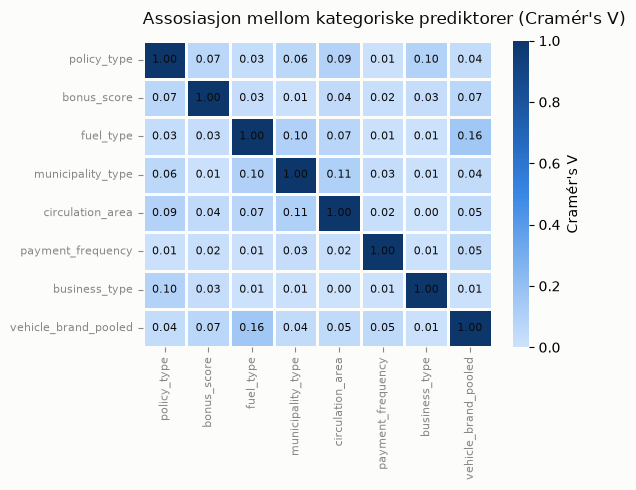

In [37]:
association_matrix = build_categorical_association(train_pool)
display(association_matrix)
display(plot_categorical_association_heatmap(association_matrix))

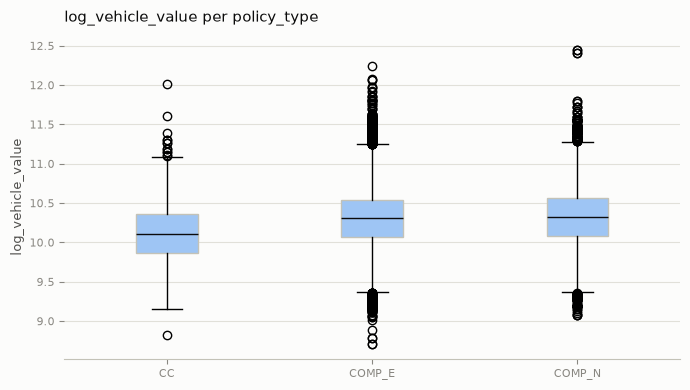

In [38]:
display(
    plot_numeric_by_category_boxplot(train_pool, "log_vehicle_value", "policy_type")
)

In [39]:
df["property_claims"].unique()

<IntegerArray>
[0, 1, 5, 3, 2, 4, 6, 8, 7, 10, 9, 15, 11]
Length: 13, dtype: Int16

# 23. Oppsummering og konsekvenser for modelleringen

## Hva analysen samlet sett viser

Analysen gir et godt nok grunnlag til å gå videre med en første modell for
egen skade, men ikke til å låse endelig modell eller endelig variabelsett.
Modellpopulasjonen består av 56 084 poliseår i 2022–2023, tilsvarende
37 904 eksponeringsår, 37 727 unike forsikringstakere og 10 126 skader.
Datamengden er stor nok for ordinære GLM-er og noen kontrollerte, ikke-lineære
effekter. Den er likevel ikke stor i alle undergrupper: særlig CC, sjeldne
bilmerker, manglende-kategorier og eventuelle interaksjoner må behandles
forsiktig.

Egen-skadedekningen utgjør omtrent 31 % av eksponeringen i hele porteføljen og
finnes bare for CC, COMP_E og COMP_N. I train-poolen dominerer COMP_E med
81,3 % av eksponeringen, mens COMP_N har 16,6 % og CC 2,1 %. Produktforskjellen
er viktig: observert skadefrekvens er omtrent 0,18 for CC og COMP_E, men 0,69
for COMP_N. Dette kan skyldes både risiko, egenandel og hvordan skader
registreres. `policy_type` må derfor være med fra starten; den er mer enn en
vanlig kontrollvariabel og beskriver ulike forsikringsvilkår.

Skadeutfallet er nulltungt og høyreskjevt:

- 89,7 % av poliseårene har ingen registrert skade.
- Gjennomsnittlig skadeantall per rad er 0,181, mens variansen er 0,468
  (rått varians/gjennomsnitt = 2,59).
- Blant de 5 778 poliseårene med skade er uvektet gjennomsnittlig severity
  1 059 EUR, medianen 617 EUR, p99 7 973 EUR og maksimum 27 333 EUR.
- Porteføljens eksponeringsvektede frekvens er 0,267 skader per poliseår og
  samlet ren premie er omtrent 232 EUR per eksponeringsår.
- Ren premie per enkelt rad har en ekstrem hale. Maksimum på 1,19 mill. EUR
  er en annualisert rate fra en skade på en svært kort eksponering, ikke en
  skade på 1,19 mill. EUR. Slike rater må derfor ikke tolkes som skadebeløp
  eller brukes til mekanisk trimming.
- Bare omtrent en tredel av radene har fullårseksponering. Korrekt offset og
  vekting er derfor avgjørende; radantall er ikke det samme som risikovolum.

Det rå spredningsforholdet er et tydelig varsel om at en enkel Poisson-modell
kan bli for snever, men det beviser ikke at negativ binomial er nødvendig.
Beregningen er ujustert for ulik eksponering og ulik risikosammensetning.
Dette avgjøres først etter at en Poisson-GLM med korrekt offset og sentrale
risikofaktorer er tilpasset, ved å undersøke residualdispersjon, kalibrering
og ytelse utenfor tilpasningsdataene. Den store nullandelen er heller ikke i
seg selv grunnlag for en nullinflasjonsmodell.

Severity og positiv ren premie passer beskrivende bedre til lognormal enn til
Gamma målt med AIC, men ingen av fordelingene beskriver halen perfekt, og
lognormalitet avvises klart. Sammenligningen er dessuten gjort på
gjennomsnittlig skade per poliseår, ikke på individuelle skader. Den sier
derfor lite om hvilken GLM som predikerer forventet kostnad best. Gamma med
log-link er fortsatt et naturlig startpunkt for severity, med skadeantall som
vekt når responsen er `property_incurred / property_claims`. Lognormal kan
brukes som en utfordrermodell. De ni skadeårene med null eller praktisk talt
null incurred må avklares og kan ikke inngå uendret i en Gamma-modell.

Fra 2022 til 2023 øker frekvensen fra 0,235 til 0,282 (omtrent 20 %), severity
faller fra 935 til 843 EUR (omtrent 10 %), og ren premie øker fra 220 til
238 EUR (omtrent 8 %). Dette kan være en reell tidseffekt, men også skyldes
endret porteføljemiks, skadeoppgjørsmodning eller tilfeldig variasjon.
Kalenderår kan brukes som kategorisk kontroll eller til senere rekalibrering;
det er **ikke** en offset. To treningsår er for lite til å estimere en stabil
lineær trend eller skadeinflasjon.

## Implikasjoner for variabelvalg

One-way-analysene viser flere plausible kandidater, men er ikke kausale og
skal ikke brukes som en automatisk utvelgelsesregel. Effektene kan endres når
variablene vurderes samtidig.

- **Høy prioritet:** `policy_type` har klart størst produktmessig betydning.
  `bonus_score` har en sterk, monoton gradient i frekvens og ren premie
  (omtrent 224, 351 og 567 EUR for G, N og B), men tas bare med dersom
  tidspunktet for fastsettelsen kan dokumenteres som leakage-fritt.
- **Kjøretøy:** Ren premie stiger tydelig med `log_vehicle_value` og
  `performance_hp_per_tonne`, særlig i øverste intervall. Begge bør prøves som
  kontinuerlige, fleksible ledd, for eksempel splines. Korrelasjonen på 0,56
  betyr at stabilitet og marginalt bidrag må kontrolleres når begge er med.
- **Alder og erfaring:** `driver_age` og `driving_experience_years` har
  korrelasjon 0,88 og bør ikke uten videre inngå som to lineære hovedledd.
  Alder viser tegn til en ikke-lineær effekt, med høyere frekvens blant de
  eldste. Sammenlign fleksible aldersledd med en alternativ
  erfaringsspesifikasjon i CV. `driver_age` er den sikreste hovedkandidaten
  fordi den utledede erfaringen bygger på en ikke fullt verifisert
  datatolkning.
- **Geografi og kontrakt:** Diesel, urbant område, innland, kvartalsbetaling
  og eksisterende portefølje har høyere observerte rater enn
  sammenligningsgruppene. De er relevante kandidater, men forskjellene kan
  være sammensetningseffekter. Det må også avklares at alle feltene er kjent
  på prisingsdatoen og er akseptable tariffkriterier.
- **Bilmerke:** Poolingen er leakage-sikker og beholder 17 merker som dekker
  88,5 % av train-eksponeringen. One-way-ratene varierer, men merke henger
  sammen med blant annet verdi og ytelse. Behold pooled merke som kandidat,
  og krev dokumentert forbedring og stabile effekter i CV fremfor å tolke de
  rå merkeratene direkte. Terskelen på 500 eksponeringsår bør også
  sensitivitetskontrolleres.
- **Lavere prioritet:** `seats` viser liten og lite entydig separasjon og kan
  være en tidlig kandidat for utelatelse dersom den ikke tilfører verdi i en
  multivariat modell. Lav one-way-effekt alene er likevel ikke nok til å
  forkaste variabelen.
- **Skal ikke brukes nå:** `vehicle_age` har feil eller uklar betydning og
  utelates. Rå `age_driving_licence` bør heller ikke brukes ved siden av
  utledet erfaring. Premier, skadeutfall, `insured_id` og informasjon som
  først oppstår etter prisingsdatoen skal aldri brukes som risikoprediktorer.
  `policy_status` holdes utenfor inntil det er dokumentert om statusen er kjent
  ved periodens start; den sterke rå raten for kansellerte poliser kan skyldes
  kort eksponering eller informasjon som oppstår i løpet av året.

Manglendeverdiene er få, men ikke nødvendigvis tilfeldige. Manglende
`fuel_type` (439 rader) og `vehicle_value` (33 rader) har høyere observert
frekvens enn komplette rader, men gruppene er små. Bruk en eksplisitt og
reproducerbar manglende-strategi som læres i hver CV-fold, og sørg for at
produksjonspipelinen håndterer manglende verdier og nye kategorier selv om de
ikke forekom i akkurat denne train-poolen.

## Anbefalt første modelleringsløp

1. Tilpass en enkel Poisson-frekvensmodell med `log(total_exposure)` som
   offset og et lite, forhåndsdefinert sett av hovedledd. Sammenlign deretter
   med negativ binomial på samme valideringsoppsett.
2. Tilpass en Gamma-severitymodell med log-link på positive skadebeløp, der
   gjennomsnittlig severity vektes med antall skader. Sammenlign med en
   lognormal utfordrer og undersøk kalibrering i halen.
3. Multipliser frekvens- og severityprediksjonene til forventet ren premie,
   og sammenlign denne todelte modellen med en Tweedie-GLM på ren premie med
   eksponering som vekt.
4. Legg til variabler i faglig begrunnede blokker. Velg kompleksitet etter
   forbedring i out-of-fold deviance og kalibrering, samt fortegn og stabilitet
   på tvers av foldene — ikke bare p-verdier eller one-way-rater.
5. Evaluer både samlet og innen viktige segmenter, spesielt `policy_type`,
   år, nytegning/fornyelse og store/små predikerte risikoer. Rapporter
   eksponeringsvektet kalibrering, deviance og rangering/lift.

`GroupKFold` beskytter mot at samme `insured_id` havner på begge sider av en
tilfeldig CV-fold, men tester ikke ren fremoverskuende generalisering. Med de
tilgjengelige årene bør den suppleres med en sensitivitetsanalyse der 2022
brukes til trening og 2023 til validering. Det er bare én slik tidsfold, så
resultatet må tolkes med forsiktighet. Dersom koeffisientusikkerhet skal
rapporteres, bør standardfeilene også ta hensyn til at samme forsikringstaker
kan forekomme i flere år, for eksempel ved clustering på `insured_id`.

## Må undersøkes grundigere før endelig modellering

Følgende er reelle avklaringspunkter, ikke bare ønskelige tillegg:

- **Skademodning og prisnivå:** Finn verdsettelsesdato og kontroller om
  `incurred` er like modent for alle år. Uten dette kan årsforskjeller og den
  endelige testen blande modellfeil med etterslep i reserver. Avklar også om
  beløpene skal inflasjonsjusteres til samme prisnivå.
- **Egen-skadedekning:** Positiv premie er bare en proxy for aktiv dekning.
  De to egen-skadesakene med null egen-skadepremie må undersøkes, og
  dekningsregelen bør valideres mot produktvilkår eller et faktisk
  dekningsflagg. Ellers kan modellpopulasjonen være selektert feil. I tillegg
  kjøres unntakskontrollen i seksjon 11 på det allerede filtrerte `df`, slik
  at den tomme unntakstabellen er sann per konstruksjon og ikke validerer hva
  som falt utenfor. Kontrollen må kjøres på `data` før filteret anvendes.
- **Eksponering og kansellering:** Kontroller frekvens og datakvalitet særskilt
  for svært korte eksponeringer og kansellerte poliser. Avklar om skader kan
  påvirke opphørstidspunkt/status. Den ekstreme annualiserte renpremien viser
  hvorfor dette er viktig.
- **Nullkostnadsskader og mange skader:** Undersøk de ni skadeårene med null
  eller nær-null incurred og poliseårene med svært mange skader (opptil 15).
  Avklar om dette er reelle nullskader, reserveringsstatus, dubletter eller en
  aggregert registreringspraksis.
- **Holdout-disiplin:** 2024 er omtalt som urørt test, men seksjon 12 viser
  allerede skadeantall, skadeandel og incurred for 2024. Holdout-resultatet er
  derfor ikke helt blindt. Lås nå modellvalg og akseptansekriterier basert på
  2022–2023, og ikke bruk flere 2024-utfall før én samlet sluttevaluering.
- **Porteføljedrift:** Sammenlign prediktor- og eksponeringsfordelinger mellom
  2022, 2023 og 2024 uten å bruke 2024-skadeutfall. Sjekk særlig produktmiks,
  nytegning/fornyelse, bonus, bilverdi, ytelse og andel korte eksponeringer.
- **Bonus-timing:** Skaff en presis *as-of*-definisjon. Hvis den ikke finnes,
  bør hovedresultatet vises både med og uten `bonus_score`; eksplisitt lagget
  skadehistorikk må håndtere nytegning og manglende historikk separat.
- **Påvirkningsanalyse:** Undersøk om et lite antall store skader driver
  segmenteffekter og årsforskjeller. Vis resultater med robuste
  sensitivitetsanalyser, men ikke kapp eller slett store skader uten en
  aktuarfaglig begrunnelse.
- **Usikkerhet i one-way-rater:** Frekvensintervallene er bare omtrentlige,
  mens severity og ren premie mangler intervaller. Bruk gjerne bootstrap med
  resampling på `insured_id` for å skille stabile mønstre fra tilfeldig støy,
  særlig for små segmenter og bilmerker.

Kort sagt: Start med transparente GLM-baseliner og et begrenset sett av
faglig begrunnede variabler. De sterkeste kandidatene er produkt,
bonus (dersom timing er trygg), kjøretøyverdi, ytelse, et fleksibelt aldersledd
og noen få geografiske/kontraktsmessige faktorer. Den største risikoen nå er
ikke mangel på modellkompleksitet, men uklar skade- og variabeltiming,
skademodning, dekningsdefinisjon og at 2024-holdouten allerede er delvis sett.